# DSP391M - DATA SCIENCE CAPSTONE PROJECT
## PROGRESS REPORT 3: MODELING & EVALUATION

**Tên nhóm:** DSP391m_G7  
**Đề tài:** Tích hợp mô hình Học máy đa nguồn dữ liệu dự báo nguy cơ Đột quỵ với Ước lượng Tiêu hao Năng lượng nhân tạo (An Integrated Multi-Source Machine Learning Framework for Stroke Risk Prediction with Synthetic Energy Expenditure Estimation)
**Ngày báo cáo:** 20/06/2026

## I. TIỀN XỬ LÝ NÂNG CAO & LỰA CHỌN ĐẶC TRƯNG (FEATURE ENGINEERING)

### 1.1. Chuẩn bị dữ liệu và tiền xử lý
Dữ liệu sử dụng trong Report 3 là dữ liệu đã được xử lý từ Report 2. Trong notebook này, nhóm chỉ kiểm tra lại tính sẵn sàng của dữ liệu và thực hiện thêm một số biến đổi đặc trưng nếu cần để phục vụ quá trình huấn luyện mô hình.

Chúng tôi tiến hành tải các tập dữ liệu `stroke_train_processed.csv`, `stroke_val_processed.csv`, và `stroke_test_processed.csv`. Nhóm thực hiện các kiểm tra nhanh để xác nhận:
- Kích thước các tập dữ liệu Train/Val/Test.
- Phân phối phân lớp của biến mục tiêu `stroke_target`.
- Tỷ lệ mẫu đột quỵ trong từng tập dữ liệu.
- Sự hiện diện của giá trị thiếu (missing values) và số hàng trùng lặp (duplicated rows).
- Sự đồng nhất về cấu trúc cột giữa ba tập dữ liệu.

In [1]:
# Code cell: Data loading and verification
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix, average_precision_score, brier_score_loss, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

# Imblearn imports
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier, RUSBoostClassifier
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Advanced algorithms
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# SHAP
import shap

train_path = 'stroke_train_processed.csv'
val_path = 'stroke_val_processed.csv'
test_path = 'stroke_test_processed.csv'

# Load datasets
df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)
df_test = pd.read_csv(test_path)

# Verify Shapes
print("=== Dataset Shapes ===")
print(f"  Train Set: {df_train.shape[0]:,} rows, {df_train.shape[1]} columns")
print(f"  Validation Set: {df_val.shape[0]:,} rows, {df_val.shape[1]} columns")
print(f"  Test Set: {df_test.shape[0]:,} rows, {df_test.shape[1]} columns")

# Verify Target Distributions
print("\n=== Target Class Distribution & Percentage ===")
for name, df in [('Train', df_train), ('Validation', df_val), ('Test', df_test)]:
    counts = df['stroke_target'].value_counts()
    pcts = df['stroke_target'].value_counts(normalize=True) * 100
    print(f"  {name} Set:")
    print(f"    Class 0 (Non-stroke): {counts.get(0, 0):,} ({pcts.get(0, 0.0):.2f}%)")
    print(f"    Class 1 (Stroke):     {counts.get(1, 0):,} ({pcts.get(1, 0.0):.2f}%)")

# Verify Missing Values
print("\n=== Missing Values ===")
print(f"  Train Null Count:      {df_train.isnull().sum().sum()}")
print(f"  Validation Null Count: {df_val.isnull().sum().sum()}")
print(f"  Test Null Count:       {df_test.isnull().sum().sum()}")

# Verify Duplicates
print("\n=== Duplicated Rows ===")
print(f"  Train Duplicates:      {df_train.duplicated().sum()}")
print(f"  Validation Duplicates: {df_val.duplicated().sum()}")
print(f"  Test Duplicates:       {df_test.duplicated().sum()}")

# Verify Column Alignment
cols_train = list(df_train.columns)
cols_val = list(df_val.columns)
cols_test = list(df_test.columns)

assert cols_train == cols_val == cols_test, "Error: Column structures or feature orders do not align!"
print("\n[SUCCESS] Feature alignment check passed. All splits have identical columns and order.")


=== Dataset Shapes ===
  Train Set: 3,577 rows, 28 columns
  Validation Set: 766 rows, 28 columns
  Test Set: 767 rows, 28 columns

=== Target Class Distribution & Percentage ===
  Train Set:
    Class 0 (Non-stroke): 3,403 (95.14%)
    Class 1 (Stroke):     174 (4.86%)
  Validation Set:
    Class 0 (Non-stroke): 729 (95.17%)
    Class 1 (Stroke):     37 (4.83%)
  Test Set:
    Class 0 (Non-stroke): 729 (95.05%)
    Class 1 (Stroke):     38 (4.95%)

=== Missing Values ===
  Train Null Count:      0
  Validation Null Count: 0
  Test Null Count:       0

=== Duplicated Rows ===
  Train Duplicates:      0
  Validation Duplicates: 0
  Test Duplicates:       0

[SUCCESS] Feature alignment check passed. All splits have identical columns and order.


### 1.2. Thiết lập mô hình cơ sở đối chứng (Baseline Dummy Classifier)
Chúng tôi thiết lập một mô hình `DummyClassifier` sử dụng chiến lược luôn dự đoán lớp đa số (không có đột quỵ) làm mô hình baseline đối chứng cơ bản. Điều này giúp kiểm chứng trực quan tính vô dụng của độ chính xác tổng thể (Accuracy) trên các tập dữ liệu mất cân bằng cực đoan.

In [2]:
# Code cell: Baseline Dummy Classifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# Split features and labels
X_train = df_train.drop(columns=['patient_id', 'stroke_target'])
y_train = df_train['stroke_target']
X_val = df_val.drop(columns=['patient_id', 'stroke_target'])
y_val = df_val['stroke_target']
X_test = df_test.drop(columns=['patient_id', 'stroke_target'])
y_test = df_test['stroke_target']

# Train Dummy Classifier
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)
y_prob_dummy = np.full(len(y_val), y_train.mean())

# Calculate Metrics
tn, fp, fn, tp = confusion_matrix(y_val, y_pred_dummy).ravel()
acc_dummy = accuracy_score(y_val, y_pred_dummy)
prec_dummy = precision_score(y_val, y_pred_dummy, zero_division=0)
rec_dummy = recall_score(y_val, y_pred_dummy, zero_division=0)
f1_dummy = f1_score(y_val, y_pred_dummy, zero_division=0)
spec_dummy = tn / (tn + fp) if (tn + fp) > 0 else 0
bal_acc_dummy = (rec_dummy + spec_dummy) / 2
roc_auc_dummy = roc_auc_score(y_val, y_prob_dummy)
pr_auc_dummy = average_precision_score(y_val, y_prob_dummy)

print("=== BASELINE DUMMY CLASSIFIER RESULTS (VAL SET) ===")
print(f"Accuracy:          {acc_dummy:.4%}")
print(f"Precision:         {prec_dummy:.4%}")
print(f"Recall:            {rec_dummy:.4%}")
print(f"F1-score:          {f1_dummy:.4%}")
print(f"ROC-AUC:           {roc_auc_dummy:.4f}")
print(f"PR-AUC (AP):       {pr_auc_dummy:.4f} (Matches Positive Prevalence: {y_val.mean():.4f})")
print(f"Specificity:       {spec_dummy:.4%}")
print(f"Balanced Accuracy: {bal_acc_dummy:.4%}")
print(f"Confusion Matrix:\n  TN: {tn}, FP: {fp}\n  FN: {fn}, TP: {tp}")


=== BASELINE DUMMY CLASSIFIER RESULTS (VAL SET) ===
Accuracy:          95.1697%
Precision:         0.0000%
Recall:            0.0000%
F1-score:          0.0000%
ROC-AUC:           0.5000
PR-AUC (AP):       0.0483 (Matches Positive Prevalence: 0.0483)
Specificity:       100.0000%
Balanced Accuracy: 50.0000%
Confusion Matrix:
  TN: 729, FP: 0
  FN: 37, TP: 0


### 1.3. Tạo đặc trưng bổ sung lâm sàng (Feature Engineering)
Để cải thiện độ nhạy và hiệu năng chung của mô hình học máy, nhóm tiến hành xây dựng thêm các đặc trưng nguy cơ lâm sàng dựa trên các giá trị thô chưa chuẩn hóa từ file gốc `Stroke_dt.csv` (như độ tuổi thực tế, mức đường huyết thực tế, chỉ số BMI). Các đặc trưng bổ sung này bao gồm:
- **Biến tương tác (Interactions):** `age_x_hypertension` (tuổi x cao huyết áp), `age_x_glucose` (tuổi x đường huyết), `bmi_x_glucose` (BMI x đường huyết), v.v.
- **Cờ nguy cơ lâm sàng (Risk Flags):** `old_and_hypertension` (cao tuổi bị huyết áp cao), `old_and_heart_disease` (cao tuổi bị tim mạch), `old_and_high_glucose` (cao tuổi bị đường huyết cao), v.v.
- **Phân nhóm lâm sàng (Risk Bins):** Phân nhóm tuổi (`age_group`), nhóm BMI (`bmi_category`), nhóm đường huyết (`glucose_category`).
- **Chỉ số rủi ro lâm sàng tổng hợp:** `multi_risk_count` (số yếu tố rủi ro tích lũy) và `clinical_risk_score_simple` (điểm nguy cơ dựa trên trọng số lâm sàng của các bệnh nền).

*Nguyên tắc nghiêm ngặt:* Việc điền giá trị thiếu BMI gốc sử dụng trung vị BMI của riêng tập huấn luyện (train set) để ngăn chặn rò rỉ thông tin (data leakage). Các đặc trưng này chỉ được sử dụng nếu chúng cải thiện hiệu năng chung trên tập Validation.

In [3]:
# Code cell: Feature Engineering
raw_stroke_path = r"../Stroke_dt/Stroke_dt.csv"
if not os.path.exists(raw_stroke_path):
    raw_stroke_path = r"Stroke_dt-20260619T002836Z-3-001/Stroke_dt/Stroke_dt.csv"

raw_df = pd.read_csv(raw_stroke_path)

# Clean BMI outliers using same logic as Report 2
def clean_bmi(series):
    values = pd.to_numeric(series, errors='coerce')
    return values.mask((values < 10) | (values > 80))
raw_df['bmi'] = clean_bmi(raw_df['bmi'])

# Deduplicate raw patient-level records
aggregations = {}
for col in raw_df.columns:
    if col == 'patient_id':
        continue
    if col == 'stroke_target':
        aggregations[col] = 'max'
    elif pd.api.types.is_numeric_dtype(raw_df[col]):
        aggregations[col] = 'median'
    else:
        aggregations[col] = lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'
raw_dedup = raw_df.groupby('patient_id', as_index=False).agg(aggregations)

# Split for raw median imputation
from sklearn.model_selection import train_test_split
raw_train, _ = train_test_split(raw_dedup, test_size=0.3, random_state=42, stratify=raw_dedup['stroke_target'])
train_bmi_median = raw_train['bmi'].median()

def add_features(df_processed):
    df = df_processed.copy()
    raw_sub = raw_dedup[['patient_id', 'age', 'avg_glucose_level', 'bmi']].copy().rename(
        columns={'age': 'age_raw', 'avg_glucose_level': 'glucose_raw', 'bmi': 'bmi_raw'}
    )
    df = df.merge(raw_sub, on='patient_id', how='left')
    df['bmi_raw'] = df['bmi_raw'].fillna(train_bmi_median)
    
    # Interactions
    df['age_x_hypertension'] = df['age'] * df['hypertension']
    df['age_x_heart_disease'] = df['age'] * df['heart_disease']
    df['age_x_glucose'] = df['age'] * df['avg_glucose_level']
    df['bmi_x_glucose'] = df['bmi'] * df['avg_glucose_level']
    df['hypertension_and_heart_disease'] = df['hypertension'] * df['heart_disease']
    
    # Flags
    df['old_and_hypertension'] = ((df['age_raw'] >= 60) & (df['hypertension'] == 1)).astype(float)
    df['old_and_heart_disease'] = ((df['age_raw'] >= 60) & (df['heart_disease'] == 1)).astype(float)
    df['old_and_high_glucose'] = ((df['age_raw'] >= 60) & (df['glucose_raw'] >= 140)).astype(float)
    df['high_glucose_and_high_bmi'] = ((df['glucose_raw'] >= 140) & (df['bmi_raw'] >= 30)).astype(float)
    
    # Bins
    df['age_group'] = pd.cut(df['age_raw'], bins=[-1, 18, 45, 65, 120], labels=[0.0, 1.0, 2.0, 3.0]).astype(float)
    df['bmi_category'] = pd.cut(df['bmi_raw'], bins=[-1, 18.5, 25, 30, 150], labels=[0.0, 1.0, 2.0, 3.0]).astype(float)
    df['glucose_category'] = pd.cut(df['glucose_raw'], bins=[-1, 100, 125, 500], labels=[0.0, 1.0, 2.0]).astype(float)
    
    # Multi risk factor count & clinical risk score
    smoke_active = ((df['smoking_status_smokes'] == 1.0) | (df['smoke_flag'] == 1.0)).astype(int)
    
    df['multi_risk_count'] = (
        (df['age_raw'] >= 60).astype(int) +
        (df['hypertension'] == 1).astype(int) +
        (df['heart_disease'] == 1).astype(int) +
        (df['glucose_raw'] >= 140).astype(int) +
        (df['bmi_raw'] >= 30).astype(int) +
        smoke_active
    ).astype(float)
    
    df['clinical_risk_score_simple'] = (
        2.0 * (df['age_raw'] >= 60).astype(float) +
        1.5 * (df['hypertension'] == 1).astype(float) +
        1.5 * (df['heart_disease'] == 1).astype(float) +
        1.0 * (df['glucose_raw'] >= 140).astype(float) +
        1.0 * (df['bmi_raw'] >= 30).astype(float) +
        0.5 * smoke_active.astype(float)
    )
    
    return df.drop(columns=['age_raw', 'glucose_raw', 'bmi_raw'])

df_train_eng = add_features(df_train)
df_val_eng = add_features(df_val)
df_test_eng = add_features(df_test)

X_train_eng = df_train_eng.drop(columns=['patient_id', 'stroke_target'])
X_val_eng = df_val_eng.drop(columns=['patient_id', 'stroke_target'])
X_test_eng = df_test_eng.drop(columns=['patient_id', 'stroke_target'])

print("=== Engineered Feature Datasets ===")
print(f"  Train Set:      {X_train_eng.shape[0]:,} rows, {X_train_eng.shape[1]} columns")
print(f"  Validation Set: {X_val_eng.shape[0]:,} rows, {X_val_eng.shape[1]} columns")
print(f"  Test Set:       {X_test_eng.shape[0]:,} rows, {X_test_eng.shape[1]} columns")


=== Engineered Feature Datasets ===
  Train Set:      3,577 rows, 40 columns
  Validation Set: 766 rows, 40 columns
  Test Set:       767 rows, 40 columns


## II. XÂY DỰNG MÔ HÌNH (MODEL DEVELOPMENT)

### 2.1. Mục tiêu mô hình và Lựa chọn thuật toán
Mục tiêu cốt lõi của nghiên cứu là phát triển một công cụ hỗ trợ sàng lọc nguy cơ đột quỵ ban đầu. Do đột quỵ là một biến cố y khoa khẩn cấp và nguy hiểm, việc bỏ sót ca bệnh (Âm tính giả - False Negative) để lại hậu quả đe dọa tính mạng người bệnh. Do đó, độ nhạy (Recall/Sensitivity) được ưu tiên tối đa. Tuy nhiên, mô hình sàng lọc y tế lý tưởng cũng cần giữ độ chính xác (Accuracy) và độ đặc hiệu (Specificity) ở mức chấp nhận được để tránh gây cảnh báo giả quá nhiều (False Positive), làm quá tải nguồn lực y tế cận lâm sàng và gây lo lắng dư thừa cho người dân.

Để giải quyết bài toán phân loại nhị phân trên dữ liệu mất cân bằng lớp (~4.87% đột quỵ), nhóm triển khai huấn luyện nhiều thuật toán học máy:
1. **Logistic Regression:** Mô hình baseline tuyến tính đơn giản, dễ giải thích ý nghĩa sinh học của các hệ số.
2. **Random Forest & Extra Trees:** Các mô hình ensemble dạng bagging giúp kiểm soát tốt phương sai và xử lý các tương tác phi tuyến.
3. **Gradient Boosting & HistGradientBoosting:** Các mô hình boosting tối ưu hóa hàm mất mát tuần tự cực kỳ hiệu quả cho dữ liệu tabular.
4. **XGBoost, LightGBM & CatBoost:** Các thuật toán boosting hiện đại được tích hợp sẵn cơ chế phạt và xử lý lệch lớp.
5. **Balanced Random Forest & Easy Ensemble:** Các thuật toán ensemble được thiết kế chuyên biệt cho dữ liệu mất cân bằng.
6. **Stacking Classifier & Voting Classifier:** Các phương pháp ensemble nâng cao giúp tổng hợp xác suất dự báo từ các mô hình thành viên tốt nhất.

In [4]:
# Code cell: Imbalance Handling Comparison
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import BorderlineSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

strategies = {
    'Balanced Weight': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Custom Weight 1:3': LogisticRegression(class_weight={0:1, 1:3}, max_iter=1000, random_state=42),
    'Custom Weight 1:5': LogisticRegression(class_weight={0:1, 1:5}, max_iter=1000, random_state=42),
    'Custom Weight 1:8': LogisticRegression(class_weight={0:1, 1:8}, max_iter=1000, random_state=42),
    'Custom Weight 1:10': LogisticRegression(class_weight={0:1, 1:10}, max_iter=1000, random_state=42),
    'SMOTE Pipeline': ImbPipeline([('smote', SMOTE(random_state=42)), ('lr', LogisticRegression(max_iter=1000, random_state=42))]),
    'BorderlineSMOTE': ImbPipeline([('bsmote', BorderlineSMOTE(random_state=42)), ('lr', LogisticRegression(max_iter=1000, random_state=42))]),
    'ADASYN': ImbPipeline([('adasyn', ADASYN(random_state=42)), ('lr', LogisticRegression(max_iter=1000, random_state=42))]),
    'SMOTEENN': ImbPipeline([('smoteenn', SMOTEENN(random_state=42)), ('lr', LogisticRegression(max_iter=1000, random_state=42))]),
    'SMOTETomek': ImbPipeline([('smotetomek', SMOTETomek(random_state=42)), ('lr', LogisticRegression(max_iter=1000, random_state=42))]),
    'RandomUnderSampler': ImbPipeline([('rus', RandomUnderSampler(random_state=42)), ('lr', LogisticRegression(max_iter=1000, random_state=42))]),
    'Balanced RF': BalancedRandomForestClassifier(random_state=42),
    'Easy Ensemble': EasyEnsembleClassifier(random_state=42),
    'RUSBoost': RUSBoostClassifier(random_state=42)
}

print("Strategy | Recall | Accuracy | Specificity | F1-score | PR-AUC | FP | FN")
print("-" * 80)
for name, model in strategies.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    acc = accuracy_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    spec = tn / (tn + fp)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    pr_auc = average_precision_score(y_val, y_prob)
    
    print(f"{name:<18} | {rec:.4%} | {acc:.4%} | {spec:.4%} | {f1:.4%} | {pr_auc:.4f} | {fp:3d} | {fn:2d}")


Strategy | Recall | Accuracy | Specificity | F1-score | PR-AUC | FP | FN
--------------------------------------------------------------------------------
Balanced Weight    | 75.6757% | 72.8460% | 72.7023% | 21.2121% | 0.1577 | 199 |  9
Custom Weight 1:3  | 5.4054% | 92.9504% | 97.3937% | 6.8966% | 0.1501 |  19 | 35
Custom Weight 1:5  | 32.4324% | 89.0339% | 91.9067% | 22.2222% | 0.1568 |  59 | 25
Custom Weight 1:8  | 54.0541% | 84.5953% | 86.1454% | 25.3165% | 0.1581 | 101 | 17
Custom Weight 1:10 | 64.8649% | 83.1593% | 84.0878% | 27.1186% | 0.1569 | 116 | 13


SMOTE Pipeline     | 75.6757% | 72.8460% | 72.7023% | 21.2121% | 0.1807 | 199 |  9
BorderlineSMOTE    | 64.8649% | 79.2428% | 79.9726% | 23.1884% | 0.1634 | 146 | 13
ADASYN             | 75.6757% | 71.9321% | 71.7421% | 20.6642% | 0.1783 | 206 |  9


SMOTEENN           | 81.0811% | 69.0601% | 68.4499% | 20.2020% | 0.1724 | 230 |  7
SMOTETomek         | 75.6757% | 72.8460% | 72.7023% | 21.2121% | 0.1809 | 199 |  9
RandomUnderSampler | 75.6757% | 69.7128% | 69.4102% | 19.4444% | 0.1640 | 223 |  9


Balanced RF        | 62.1622% | 78.4595% | 79.2867% | 21.8009% | 0.1434 | 151 | 14


Easy Ensemble      | 86.4865% | 69.3211% | 68.4499% | 21.4047% | 0.1424 | 230 |  5
RUSBoost           | 56.7568% | 79.1123% | 80.2469% | 20.7921% | 0.1133 | 144 | 16


### 2.2. Huấn luyện mô hình và Tinh chỉnh siêu tham số (Hyperparameter Tuning)
Để tối ưu hóa hiệu năng của các mô hình đơn lẻ độc lập với nguy cơ overfitting, nhóm thực hiện tinh chỉnh siêu tham số bằng phương pháp tìm kiếm ngẫu nhiên `RandomizedSearchCV` kết hợp kỹ thuật Stratified 5-Fold Cross-Validation trên tập huấn luyện (Train set). Chỉ số tối ưu hóa được sử dụng là độ chuẩn xác trung bình (`average_precision`), giúp tập trung cải thiện hiệu năng dự đoán trên lớp thiểu số (bệnh đột quỵ).

In [5]:
# Code cell: Hyperparameter Tuning
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tuned_models = {}

# Imbalance ratio
imbalance_ratio = (len(y_train) - y_train.sum()) / y_train.sum()

# 1. Logistic Regression
print("Tuning Logistic Regression...")
lr_param_grid = {
    'C': np.logspace(-3, 3, 10),
    'penalty': ['l2'],
    'solver': ['liblinear'],
    'class_weight': ['balanced', None]
}
lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_distributions=lr_param_grid,
    n_iter=10,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
lr_search.fit(X_train, y_train)
tuned_models['Logistic Regression'] = lr_search.best_estimator_

# 2. Random Forest
print("Tuning Random Forest...")
rf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)
tuned_models['Random Forest'] = rf_search.best_estimator_

# 3. Extra Trees
print("Tuning Extra Trees...")
et_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 8],
    'class_weight': ['balanced', 'balanced_subsample']
}
et_search = RandomizedSearchCV(
    ExtraTreesClassifier(random_state=42),
    param_distributions=et_param_grid,
    n_iter=10,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
et_search.fit(X_train, y_train)
tuned_models['Extra Trees'] = et_search.best_estimator_

# 4. Gradient Boosting
print("Tuning Gradient Boosting...")
gb_param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.6, 0.8, 1.0]
}
gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=gb_param_grid,
    n_iter=10,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
gb_search.fit(X_train, y_train)
tuned_models['Gradient Boosting'] = gb_search.best_estimator_

# 5. HistGradientBoosting
print("Tuning HistGradientBoosting...")
hgb_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [50, 100, 150],
    'max_depth': [3, 5],
    'class_weight': ['balanced', None]
}
hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_distributions=hgb_param_grid,
    n_iter=10,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
hgb_search.fit(X_train, y_train)
tuned_models['HistGradientBoosting'] = hgb_search.best_estimator_

# 6. XGBoost
print("Tuning XGBoost...")
xgb_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'scale_pos_weight': [0.5 * imbalance_ratio, 1.0 * imbalance_ratio, 1.5 * imbalance_ratio, 2.0 * imbalance_ratio]
}
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=10,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_train, y_train)
tuned_models['XGBoost'] = xgb_search.best_estimator_

# 7. LightGBM
print("Tuning LightGBM...")
lgb_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'num_leaves': [15, 31, 63],
    'class_weight': ['balanced', None]
}
lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=lgb_param_grid,
    n_iter=10,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
lgb_search.fit(X_train, y_train)
tuned_models['LightGBM'] = lgb_search.best_estimator_

# 8. CatBoost
print("Tuning CatBoost...")
cat_param_grid = {
    'iterations': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [3, 5, 7],
    'auto_class_weights': ['Balanced', 'SqrtBalanced']
}
cat_search = RandomizedSearchCV(
    CatBoostClassifier(random_seed=42, verbose=0),
    param_distributions=cat_param_grid,
    n_iter=10,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
cat_search.fit(X_train, y_train)
tuned_models['CatBoost'] = cat_search.best_estimator_

print("\n[SUCCESS] Hyperparameter tuning complete.")


Tuning Logistic Regression...


Tuning Random Forest...


Tuning Extra Trees...


Tuning Gradient Boosting...


Tuning HistGradientBoosting...


Tuning XGBoost...


Tuning LightGBM...


Tuning CatBoost...



[SUCCESS] Hyperparameter tuning complete.


### 2.3. Mô hình Ensemble nâng cao và Calibrated Classifiers
Sau khi có các mô hình đơn lẻ tốt nhất, chúng tôi xây dựng mô hình Stacking Classifier và Voting Classifier để kết hợp sức mạnh của chúng. Đồng thời, nhóm thực hiện hiệu chuẩn xác suất (Probability Calibration) bằng phương pháp Sigmoid và Isotonic sử dụng `CalibratedClassifierCV` trên 5-Fold Cross-Validation nhằm hiệu chỉnh các xác suất dự báo về sát với tần suất thực tế của lớp đột quỵ.

In [6]:
# Code cell: Advanced Classifiers and Calibration
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.calibration import CalibratedClassifierCV

# Initialize Advanced Classifiers
adv_models = {
    'Balanced RF': BalancedRandomForestClassifier(random_state=42),
    'Easy Ensemble': EasyEnsembleClassifier(random_state=42)
}

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

base_estimators = [
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42)),
    ('hgb', HistGradientBoostingClassifier(class_weight='balanced', random_state=42))
]

adv_models['Stacking Classifier'] = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(random_state=42),
    cv=cv,
    n_jobs=-1
)

adv_models['Voting Classifier'] = VotingClassifier(
    estimators=base_estimators,
    voting='soft'
)

# Train advanced models on Standard Features
for name, model in adv_models.items():
    model.fit(X_train, y_train)

# Calibration Testing using internal StratifiedKFold cv=5
calibrated_models = {
    'LR (Calibrated Sigmoid)': CalibratedClassifierCV(tuned_models['Logistic Regression'], cv=5, method='sigmoid'),
    'LR (Calibrated Isotonic)': CalibratedClassifierCV(tuned_models['Logistic Regression'], cv=5, method='isotonic'),
    'CatBoost (Calibrated Isotonic)': CalibratedClassifierCV(tuned_models['CatBoost'], cv=5, method='isotonic'),
    'Stacking (Calibrated Isotonic)': CalibratedClassifierCV(
        StackingClassifier(estimators=base_estimators, final_estimator=LogisticRegression(random_state=42), cv=cv, n_jobs=-1),
        cv=5, method='isotonic'
    ),
    'Stacking (Calibrated Sigmoid)': CalibratedClassifierCV(
        StackingClassifier(estimators=base_estimators, final_estimator=LogisticRegression(random_state=42), cv=cv, n_jobs=-1),
        cv=5, method='sigmoid'
    )
}

for name, model in calibrated_models.items():
    model.fit(X_train, y_train)

print("[SUCCESS] Advanced classifiers and calibrated models trained successfully.")


[SUCCESS] Advanced classifiers and calibrated models trained successfully.


## III. ĐÁNH GIÁ VÀ TINH CHỈNH (EVALUATION & TUNING)

### 3.1. Đánh giá hiệu năng đa chỉ số
Do tỷ lệ mẫu đột quỵ rất nhỏ (~4.87%), Accuracy (Độ chính xác) đơn thuần là chỉ số rất dễ gây hiểu nhầm. Nhóm tiến hành đánh giá toàn diện các mô hình dựa trên nhiều metric bổ trợ: Accuracy, Precision, Recall/Sensitivity, Specificity, Balanced Accuracy, F1-score, ROC-AUC, PR-AUC và Ma trận nhầm lẫn (Confusion Matrix).

### 3.2. Quét ngưỡng quyết định (Decision Threshold Optimization)
Để xác định ranh giới phân loại tối ưu giữa nguy cơ đột quỵ và bình thường, nhóm thực hiện quét các ngưỡng quyết định từ **0.01 đến 0.99 với bước 0.01** trên tập **Validation** để tối ưu hóa chỉ số lâm sàng tổng hợp tự định nghĩa `Strong_Model_Score`:
$$	ext{Strong\_Model\_Score} = 0.30 	imes 	ext{Recall} + 0.25 	imes 	ext{Accuracy} + 0.20 	imes 	ext{Specificity} + 0.15 	imes 	ext{Balanced\_Accuracy} + 0.05 	imes 	ext{F1-score} + 0.05 	imes 	ext{PR-AUC}$$
Áp dụng hình phạt nghiêm khắc cho các vi phạm chỉ số an toàn y tế lâm sàng:
- Phạt **-0.08** nếu Recall $< 0.85$ (Bắt buộc độ nhạy cao để sàng lọc).
- Phạt **-0.08** nếu Accuracy $< 0.80$ (Đảm bảo độ chính xác chung).
- Phạt **-0.05** nếu Specificity $< 0.75$ (Hạn chế báo động giả quá mức).
- Phạt **-0.05** nếu số ca Âm tính giả (FN) $> 6$ (Hạn chế tối đa bỏ sót ca bệnh thực tế).
- Phạt **-0.03** nếu số ca Dương tính giả (FP) cao hơn mức đối chứng của baseline Gradient Boosting trên Validation set.

#### Quy tắc lựa chọn mô hình và ngưỡng cuối cùng:
1. Tìm các mô hình và ngưỡng quyết định thỏa mãn: Recall $\ge 85\%$, Accuracy $\ge 80\%$, Specificity $\ge 75\%$.
2. Nếu không có mô hình nào thỏa mãn đồng thời cả 3 điều kiện, chọn mô hình/ngưỡng đạt Recall $\ge 85\%$ và có **Accuracy cao nhất trên tập Validation**.
3. Nếu Recall $\ge 85\%$ là hoàn toàn không thể đạt được, chọn mô hình/ngưỡng có `Strong_Model_Score` cao nhất trên Validation set.

*Nguyên tắc nghiêm ngặt:* Việc tối ưu hóa ngưỡng quyết định được thực hiện hoàn toàn độc lập trên tập **Validation**. Tập **Test** chỉ được sử dụng một lần duy nhất vào bước cuối cùng để đánh giá khách quan hiệu năng mô hình đã chọn.


In [7]:
# Code cell: Grid search threshold tuning
# We evaluate standard, engineered, and calibrated models using the Strong_Model_Score metric.

# Fit GB Standard to get baseline validation FP
gb_val_model = tuned_models['Gradient Boosting']
gb_val_probs = gb_val_model.predict_proba(X_val)[:, 1]
gb_val_preds = (gb_val_probs >= 0.05).astype(int)
_, gb_val_fp, _, _ = confusion_matrix(y_val, gb_val_preds).ravel()
print(f"Gradient Boosting Baseline validation FP (at 0.05): {gb_val_fp}")

test_cases = {
    # Standard Features
    'LR (Standard)': (tuned_models['Logistic Regression'], X_train, X_val, X_test),
    'RF (Standard)': (tuned_models['Random Forest'], X_train, X_val, X_test),
    'ET (Standard)': (tuned_models['Extra Trees'], X_train, X_val, X_test),
    'GB (Standard)': (tuned_models['Gradient Boosting'], X_train, X_val, X_test),
    'HGB (Standard)': (tuned_models['HistGradientBoosting'], X_train, X_val, X_test),
    'XGBoost (Standard)': (tuned_models['XGBoost'], X_train, X_val, X_test),
    'LightGBM (Standard)': (tuned_models['LightGBM'], X_train, X_val, X_test),
    'CatBoost (Standard)': (tuned_models['CatBoost'], X_train, X_val, X_test),
    'Balanced RF (Standard)': (adv_models['Balanced RF'], X_train, X_val, X_test),
    'Easy Ensemble (Standard)': (adv_models['Easy Ensemble'], X_train, X_val, X_test),
    'Stacking (Standard)': (adv_models['Stacking Classifier'], X_train, X_val, X_test),
    'Voting (Standard)': (adv_models['Voting Classifier'], X_train, X_val, X_test),
    
    # Calibrated versions (Standard features)
    'LR (Calibrated Sigmoid)': (calibrated_models['LR (Calibrated Sigmoid)'], X_train, X_val, X_test),
    'LR (Calibrated Isotonic)': (calibrated_models['LR (Calibrated Isotonic)'], X_train, X_val, X_test),
    'CatBoost (Calibrated Isotonic)': (calibrated_models['CatBoost (Calibrated Isotonic)'], X_train, X_val, X_test),
    'Stacking (Calibrated Isotonic)': (calibrated_models['Stacking (Calibrated Isotonic)'], X_train, X_val, X_test),
    'Stacking (Calibrated Sigmoid)': (calibrated_models['Stacking (Calibrated Sigmoid)'], X_train, X_val, X_test),
    
    # Engineered features versions
    'LR (Engineered)': (LogisticRegression(class_weight='balanced', solver='liblinear', penalty='l2', C=0.464, max_iter=1000, random_state=42).fit(X_train_eng, y_train), X_train_eng, X_val_eng, X_test_eng),
    'RF (Engineered)': (RandomForestClassifier(n_estimators=50, max_depth=5, class_weight='balanced_subsample', random_state=42).fit(X_train_eng, y_train), X_train_eng, X_val_eng, X_test_eng),
    'ET (Engineered)': (ExtraTreesClassifier(class_weight='balanced', random_state=42).fit(X_train_eng, y_train), X_train_eng, X_val_eng, X_test_eng),
    'GB (Engineered)': (GradientBoostingClassifier(random_state=42).fit(X_train_eng, y_train), X_train_eng, X_val_eng, X_test_eng),
    'HGB (Engineered)': (HistGradientBoostingClassifier(class_weight='balanced', random_state=42).fit(X_train_eng, y_train), X_train_eng, X_val_eng, X_test_eng),
    'XGBoost (Engineered)': (xgb.XGBClassifier(scale_pos_weight=imbalance_ratio, eval_metric='logloss', random_state=42).fit(X_train_eng, y_train), X_train_eng, X_val_eng, X_test_eng),
    'LightGBM (Engineered)': (lgb.LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1).fit(X_train_eng, y_train), X_train_eng, X_val_eng, X_test_eng),
    'CatBoost (Engineered)': (CatBoostClassifier(auto_class_weights='Balanced', random_seed=42, verbose=0).fit(X_train_eng, y_train), X_train_eng, X_val_eng, X_test_eng),
    'Balanced RF (Engineered)': (BalancedRandomForestClassifier(random_state=42).fit(X_train_eng, y_train), X_train_eng, X_val_eng, X_test_eng),
    'Easy Ensemble (Engineered)': (EasyEnsembleClassifier(random_state=42).fit(X_train_eng, y_train), X_train_eng, X_val_eng, X_test_eng),
    'Stacking (Engineered)': (StackingClassifier(estimators=base_estimators, final_estimator=LogisticRegression(random_state=42), cv=cv, n_jobs=-1).fit(X_train_eng, y_train), X_train_eng, X_val_eng, X_test_eng),
    'Voting (Engineered)': (VotingClassifier(estimators=base_estimators, voting='soft').fit(X_train_eng, y_train), X_train_eng, X_val_eng, X_test_eng)
}

thresholds = np.arange(0.01, 1.00, 0.01)
best_val_rows_bal = {}
threshold_curves = {}

for name, (model, xtr, xvl, xte) in test_cases.items():
    y_prob_v = model.predict_proba(xvl)[:, 1]
    pr_auc_val = average_precision_score(y_val, y_prob_v)
    
    rows_bal = []
    
    for thresh in thresholds:
        y_pred = (y_prob_v >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
        
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        bal_acc = (rec + spec) / 2
        
        # Calculate Strong_Model_Score
        score = (0.30 * rec + 
                 0.25 * acc + 
                 0.20 * spec + 
                 0.15 * bal_acc + 
                 0.05 * f1 + 
                 0.05 * pr_auc_val)
        
        # Penalties
        penalty = 0
        if rec < 0.85: penalty += 0.08
        if acc < 0.80: penalty += 0.08
        if spec < 0.75: penalty += 0.05
        if fn > 6: penalty += 0.05
        if fp > gb_val_fp: penalty += 0.03
            
        final_score = score - penalty
            
        rows_bal.append({
            'Threshold': thresh, 'Accuracy': acc, 'Precision': prec, 'Recall': rec,
            'F1-score': f1, 'Specificity': spec, 'Balanced Accuracy': bal_acc,
            'FP': fp, 'FN': fn, 'TP': tp, 'TN': tn, 'Strong_Model_Score': final_score,
            'Recall_ge_85': int(rec >= 0.85),
            'Acc_ge_80': int(acc >= 0.80),
            'Spec_ge_75': int(spec >= 0.75)
        })
        
    df_res_bal = pd.DataFrame(rows_bal)
    threshold_curves[name] = df_res_bal
    
    # Sort according to clinical hierarchy:
    # First priority: Recall >= 85%
    # Second priority: Accuracy >= 80%
    # Third priority: Specificity >= 75%
    # Fourth priority: Strong_Model_Score
    df_sorted_bal = df_res_bal.sort_values(
        by=['Recall_ge_85', 'Acc_ge_80', 'Spec_ge_75', 'Strong_Model_Score', 'Accuracy', 'Recall', 'Specificity'],
        ascending=[False, False, False, False, False, False, False]
    )
    best_val_rows_bal[name] = df_sorted_bal.iloc[0]

# Build validation comparison table
comp_data_bal = []
for name in test_cases.keys():
    best_row_bal = best_val_rows_bal[name]
    comp_data_bal.append({
        'Model': name,
        'Threshold': best_row_bal['Threshold'],
        'Accuracy': best_row_bal['Accuracy'],
        'Precision': best_row_bal['Precision'],
        'Recall': best_row_bal['Recall'],
        'F1-score': best_row_bal['F1-score'],
        'Specificity': best_row_bal['Specificity'],
        'Balanced Accuracy': best_row_bal['Balanced Accuracy'],
        'FP': int(best_row_bal['FP']),
        'FN': int(best_row_bal['FN']),
        'Strong Model Score': best_row_bal['Strong_Model_Score']
    })

val_comp_bal = pd.DataFrame(comp_data_bal)

print("=== Validation Set Optimal Thresholds (Strong Accuracy-Recall Optimization) ===")
print(val_comp_bal.sort_values(by='Strong Model Score', ascending=False).to_string(index=False))

# Identify selected final model automatically on validation
all_threshold_rows = []
for name, df_res in threshold_curves.items():
    df_copy = df_res.copy()
    df_copy['Model'] = name
    all_threshold_rows.append(df_copy)
df_all_thresh = pd.concat(all_threshold_rows, ignore_index=True)

cond_all = (df_all_thresh['Recall'] >= 0.85) & (df_all_thresh['Accuracy'] >= 0.80) & (df_all_thresh['Specificity'] >= 0.75)
sat_all = df_all_thresh[cond_all]

if len(sat_all) > 0:
    selected_row = sat_all.sort_values(by='Strong_Model_Score', ascending=False).iloc[0]
    selection_rule_msg = "Satisfies Recall >= 85%, Accuracy >= 80%, Specificity >= 75%"
else:
    rec_ok_all = df_all_thresh[df_all_thresh['Recall'] >= 0.85]
    if len(rec_ok_all) > 0:
        selected_row = rec_ok_all.sort_values(by=['Accuracy', 'Recall', 'Strong_Model_Score'], ascending=[False, False, False]).iloc[0]
        selection_rule_msg = "Recall >= 85% achieved with highest validation Accuracy (compromise on Accuracy/Specificity targets)"
    else:
        selected_row = df_all_thresh.sort_values(by='Strong_Model_Score', ascending=False).iloc[0]
        selection_rule_msg = "Recall >= 85% impossible; selected highest Strong_Model_Score on validation"

final_model_name = selected_row['Model']
final_thresh = selected_row['Threshold']

print(f"\n>>> FINAL SELECTED MODEL CONFIGURATION (FROM VALIDATION ONLY): <<<")
print(f"Model: {final_model_name}")
print(f"Threshold: {final_thresh:.2f}")
print(f"Selection Rule Applied: {selection_rule_msg}")


Gradient Boosting Baseline validation FP (at 0.05): 180


=== Validation Set Optimal Thresholds (Strong Accuracy-Recall Optimization) ===
                         Model  Threshold  Accuracy  Precision   Recall  F1-score  Specificity  Balanced Accuracy  FP  FN  Strong Model Score
 Stacking (Calibrated Sigmoid)       0.04  0.707572   0.133333 0.918919  0.232877     0.696845           0.807882 221   3            0.572515
Stacking (Calibrated Isotonic)       0.04  0.699739   0.130268 0.918919  0.228188     0.688615           0.803767 227   3            0.567942
             Voting (Standard)       0.17  0.694517   0.128302 0.918919  0.225166     0.683128           0.801023 231   3            0.565082
           Stacking (Standard)       0.04  0.699739   0.127413 0.891892  0.222973     0.689986           0.790939 226   4            0.558183
           CatBoost (Standard)       0.12  0.681462   0.123636 0.918919  0.217949     0.669410           0.794165 241   3            0.557150
       LR (Calibrated Sigmoid)       0.04  0.671018   0.120141 0.918

## IV. PHÂN TÍCH KẾT QUẢ & ĐỊNH HƯỚNG

### 4.1. So sánh kết quả các mô hình trên tập kiểm thử (Test Set)
Bảng dưới đây trình bày hiệu năng của các mô hình đối chứng cơ bản và các mô hình ứng viên tối ưu sau khi được quét ngưỡng quyết định trên tập Validation và đánh giá một lần duy nhất trên tập Test độc lập.

In [8]:
# Code cell: Test Set Evaluation
test_results = []

# Evaluate Dummy classifier first
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
y_prob_dummy = np.full(len(y_test), y_train.mean())
tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_test, y_pred_dummy).ravel()
acc_d = accuracy_score(y_test, y_pred_dummy)
prec_d = precision_score(y_test, y_pred_dummy, zero_division=0)
rec_d = recall_score(y_test, y_pred_dummy, zero_division=0)
f1_d = f1_score(y_test, y_pred_dummy, zero_division=0)
spec_d = tn_d / (tn_d + fp_d)
bal_acc_d = (rec_d + spec_d) / 2
roc_auc_d = 0.50
pr_auc_d = y_train.mean()

test_results.append({
    'Model': 'Dummy Classifier', 'Threshold': 0.50, 'Accuracy': acc_d, 'Precision': prec_d,
    'Recall': rec_d, 'Specificity': spec_d, 'Balanced Accuracy': bal_acc_d, 'F1-score': f1_d,
    'ROC-AUC': roc_auc_d, 'PR-AUC': pr_auc_d, 'FP': fp_d, 'FN': fn_d, 'TP': tp_d, 'TN': tn_d,
    'Strong_Model_Score': 0.0, 'Selection note': 'Baseline Dummy'
})

# Grid search all models on test at their optimal validation thresholds
for name, (model, xtr, xvl, xte) in test_cases.items():
    best_row = best_val_rows_bal[name]
    t = best_row['Threshold']
    
    y_prob_t = model.predict_proba(xte)[:, 1]
    y_pred_t = (y_prob_t >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    bal_acc = (rec + spec) / 2
    roc_auc = roc_auc_score(y_test, y_prob_t)
    pr_auc = average_precision_score(y_test, y_prob_t)
    
    # Calculate Strong_Model_Score on test
    test_score = (0.30 * rec + 
                  0.25 * acc + 
                  0.20 * spec + 
                  0.15 * bal_acc + 
                  0.05 * f1 + 
                  0.05 * pr_auc)
    
    penalty = 0
    if rec < 0.85: penalty += 0.08
    if acc < 0.80: penalty += 0.08
    if spec < 0.75: penalty += 0.05
    if fn > 6: penalty += 0.05
    if fp > 155: penalty += 0.03
    
    test_results.append({
        'Model': name, 'Threshold': t, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'Specificity': spec, 'Balanced Accuracy': bal_acc, 'F1-score': f1,
        'ROC-AUC': roc_auc, 'PR-AUC': pr_auc, 'FP': fp, 'FN': fn, 'TP': tp, 'TN': tn,
        'Strong_Model_Score': test_score - penalty, 'Selection note': f'Optimal Val Thresh'
    })

# Add explicit evaluations for final selected model, baselines, and alternatives
# Final Selected Model
sel_model, sel_xtr, sel_xvl, sel_xte = test_cases[final_model_name]
y_prob_sel = sel_model.predict_proba(sel_xte)[:, 1]
y_pred_sel = (y_prob_sel >= final_thresh).astype(int)
tn_sel, fp_sel, fn_sel, tp_sel = confusion_matrix(y_test, y_pred_sel).ravel()
acc_sel = accuracy_score(y_test, y_pred_sel)
prec_sel = precision_score(y_test, y_pred_sel, zero_division=0)
rec_sel = recall_score(y_test, y_pred_sel)
f1_sel = f1_score(y_test, y_pred_sel)
spec_sel = tn_sel / (tn_sel + fp_sel)
bal_acc_sel = (rec_sel + spec_sel) / 2
roc_auc_sel = roc_auc_score(y_test, y_prob_sel)
pr_auc_sel = average_precision_score(y_test, y_prob_sel)
sel_score = (0.30 * rec_sel + 0.25 * acc_sel + 0.20 * spec_sel + 0.15 * bal_acc_sel + 0.05 * f1_sel + 0.05 * pr_auc_sel)
if rec_sel < 0.85: sel_score -= 0.08
if acc_sel < 0.80: sel_score -= 0.08
if spec_sel < 0.75: sel_score -= 0.05
if fn_sel > 6: sel_score -= 0.05
if fp_sel > 155: sel_score -= 0.03

# Previous best baseline model (Gradient Boosting Standard @ 0.05 threshold)
gb_model_obj = test_cases['GB (Standard)'][0]
X_test_gb = test_cases['GB (Standard)'][3]
y_prob_gb = gb_model_obj.predict_proba(X_test_gb)[:, 1]
y_pred_gb = (y_prob_gb >= 0.05).astype(int)
tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_test, y_pred_gb).ravel()
acc_b = accuracy_score(y_test, y_pred_gb)
prec_b = precision_score(y_test, y_pred_gb, zero_division=0)
rec_b = recall_score(y_test, y_pred_gb)
f1_b = f1_score(y_test, y_pred_gb)
spec_b = tn_b / (tn_b + fp_b)
bal_acc_b = (rec_b + spec_b) / 2
roc_auc_b = roc_auc_score(y_test, y_prob_gb)
pr_auc_b = average_precision_score(y_test, y_prob_gb)
b_strong_score = (0.30 * rec_b + 0.25 * acc_b + 0.20 * spec_b + 0.15 * bal_acc_b + 0.05 * f1_b + 0.05 * pr_auc_b)
if rec_b < 0.85: b_strong_score -= 0.08
if acc_b < 0.80: b_strong_score -= 0.08
if spec_b < 0.75: b_strong_score -= 0.05
if fn_b > 6: b_strong_score -= 0.05
if fp_b > 155: b_strong_score -= 0.03

# Previous high-recall Logistic Regression at 0.04
lr_std_obj = test_cases['LR (Standard)'][0]
X_test_lr = test_cases['LR (Standard)'][3]
y_prob_lr = lr_std_obj.predict_proba(X_test_lr)[:, 1]
y_pred_lr = (y_prob_lr >= 0.04).astype(int)
tn_lr, fp_lr, fn_lr, tp_lr = confusion_matrix(y_test, y_pred_lr).ravel()
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
spec_lr = tn_lr / (tn_lr + fp_lr)
bal_acc_lr = (rec_lr + spec_lr) / 2
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
pr_auc_lr = average_precision_score(y_test, y_prob_lr)
lr_strong_score = (0.30 * rec_lr + 0.25 * acc_lr + 0.20 * spec_lr + 0.15 * bal_acc_lr + 0.05 * f1_lr + 0.05 * pr_auc_lr)
if rec_lr < 0.85: lr_strong_score -= 0.08
if acc_lr < 0.80: lr_strong_score -= 0.08
if spec_lr < 0.75: lr_strong_score -= 0.05
if fn_lr > 6: lr_strong_score -= 0.05
if fp_lr > 155: lr_strong_score -= 0.03

test_res_df = pd.DataFrame(test_results)

# Create comparison rows as pandas Series
baseline_row = pd.Series({
    'Model': 'Previous Baseline: GB (Standard)', 'Threshold': 0.05, 'Accuracy': acc_b, 'Precision': prec_b,
    'Recall': rec_b, 'Specificity': spec_b, 'Balanced Accuracy': bal_acc_b, 'F1-score': f1_b,
    'ROC-AUC': roc_auc_b, 'PR-AUC': pr_auc_b, 'FP': fp_b, 'FN': fn_b, 'TP': tp_b, 'TN': tn_b,
    'Strong_Model_Score': b_strong_score, 'Selection note': 'Previous GB Baseline'
})

prev_lr_row = pd.Series({
    'Model': 'Logistic Regression High-Recall Model', 'Threshold': 0.04, 'Accuracy': acc_lr, 'Precision': prec_lr,
    'Recall': rec_lr, 'Specificity': spec_lr, 'Balanced Accuracy': bal_acc_lr, 'F1-score': f1_lr,
    'ROC-AUC': roc_auc_lr, 'PR-AUC': pr_auc_lr, 'FP': fp_lr, 'FN': fn_lr, 'TP': tp_lr, 'TN': tn_lr,
    'Strong_Model_Score': lr_strong_score, 'Selection note': 'Previous High-Recall Alternative'
})

final_row = pd.Series({
    'Model': final_model_name, 'Threshold': final_thresh, 'Accuracy': acc_sel, 'Precision': prec_sel,
    'Recall': rec_sel, 'Specificity': spec_sel, 'Balanced Accuracy': bal_acc_sel, 'F1-score': f1_sel,
    'ROC-AUC': roc_auc_sel, 'PR-AUC': pr_auc_sel, 'FP': fp_sel, 'FN': fn_sel, 'TP': tp_sel, 'TN': tn_sel,
    'Strong_Model_Score': sel_score, 'Selection note': 'Final Selected Strong Model'
})

dummy_row = test_res_df[test_res_df['Model'] == 'Dummy Classifier'].iloc[0]
high_rec_row = test_res_df.sort_values(by='Recall', ascending=False).iloc[0]
high_acc_row = test_res_df.sort_values(by='Accuracy', ascending=False).iloc[0]
high_spec_row = test_res_df.sort_values(by='Specificity', ascending=False).iloc[0]
high_bal_row = test_res_df.sort_values(by='Balanced Accuracy', ascending=False).iloc[0]
high_pr_row = test_res_df.sort_values(by='PR-AUC', ascending=False).iloc[0]
best_score_row = test_res_df.sort_values(by='Strong_Model_Score', ascending=False).iloc[0]

summary_comp = pd.DataFrame([
    dummy_row,
    baseline_row,
    prev_lr_row,
    high_acc_row,
    high_rec_row,
    high_spec_row,
    high_bal_row,
    high_pr_row,
    best_score_row,
    final_row
])

summary_comp['Selection note'] = [
    'Dummy Classifier (No Skill)',
    'Previous GB Baseline @ 0.05',
    'Logistic Regression High-Recall Model @ 0.04',
    'Best Accuracy model',
    'Best Recall model',
    'Best Specificity model',
    'Best Balanced Accuracy model',
    'Best PR-AUC model',
    'Best Strong_Model_Score model',
    'Final Selected Strong Model'
]

print("=== CLINICAL MODEL COMPARISON TABLE (TEST SET) ===")
cols_to_print = ['Model', 'Threshold', 'Accuracy', 'Precision', 'Recall', 'Specificity', 'Balanced Accuracy', 'F1-score', 'ROC-AUC', 'PR-AUC', 'FP', 'FN', 'Strong_Model_Score', 'Selection note']
print(summary_comp[cols_to_print].to_string(index=False))


=== CLINICAL MODEL COMPARISON TABLE (TEST SET) ===
                                Model  Threshold  Accuracy  Precision   Recall  Specificity  Balanced Accuracy  F1-score  ROC-AUC   PR-AUC  FP  FN  Strong_Model_Score                               Selection note
                     Dummy Classifier       0.50  0.950456   0.000000 0.000000     1.000000           0.500000  0.000000 0.500000 0.048644   0  38            0.000000                  Dummy Classifier (No Skill)
     Previous Baseline: GB (Standard)       0.05  0.792699   0.165746 0.789474     0.792867           0.791170  0.273973 0.859848 0.202386 151   8            0.526084                  Previous GB Baseline @ 0.05
Logistic Regression High-Recall Model       0.04  0.710561   0.134921 0.894737     0.700960           0.797849  0.234483 0.847123 0.198329 218   4            0.567571 Logistic Regression High-Recall Model @ 0.04
                     Dummy Classifier       0.50  0.950456   0.000000 0.000000     1.000000          

### 4.2. Phân tích các điểm vận hành (Operating Point Analysis)
Dự báo nguy cơ đột quỵ trong sàng lọc lâm sàng đòi hỏi phải phân tích các điểm vận hành khác nhau tùy thuộc vào nguồn lực y tế thực tế và nhu cầu sàng lọc của bệnh viện. Dưới đây là phân tích 4 điểm vận hành tiêu biểu của mô hình Stacking Classifier (Calibrated Sigmoid):
- **Điểm A. Tối đa hóa Độ nhạy (Ngưỡng 0.01):** Recall đạt **97.37%** (chỉ bỏ sót 1 ca đột quỵ) nhưng Accuracy rất thấp (29.86%), tạo ra tới 537 ca báo động giả. Setting này thực tế không khả thi vì gây lãng phí nghiêm trọng tài nguyên.
- **Điểm B. Sàng lọc khuyến nghị (Ngưỡng 0.04):** Recall đạt **92.11%** (bỏ sót 3 ca), Accuracy đạt **71.06%**, Specificity đạt **69.96%**, tạo ra **219 ca cảnh báo giả**. Đây là cấu hình đề xuất chính mang lại sự cân bằng tốt nhất giữa độ nhạy cao và tỷ lệ báo động giả chấp nhận được.
- **Điểm C. Hỗ trợ lâm sàng cân bằng (Ngưỡng 0.05):** Recall giảm xuống **84.21%** (bỏ sót 6 ca), đổi lại Accuracy tăng lên **74.97%** và Specificity tăng lên **74.49%**, giảm báo động giả xuống 186 ca.
- **Điểm D. Thận trọng (Ngưỡng 0.07):** Recall đạt **78.95%** (bỏ sót 8 ca) bằng với Gradient Boosting Baseline nhưng số ca cảnh báo giả giảm đáng kể xuống **136 ca** (so với 151 ca của GB), tăng Accuracy lên **81.23%**.

In [9]:
# Code cell: Operating Point Analysis
operating_thresholds = [0.01, 0.04, 0.05, 0.08]
labels_op = ['A. Maximum Sensitivity', 'B. Recommended Screening (Selected)', 'C. Balanced Clinical-Support', 'D. Conservative']
op_results = []

for label, thresh in zip(labels_op, operating_thresholds):
    y_pred_op = (y_prob_sel >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_op).ravel()
    
    acc = accuracy_score(y_test, y_pred_op)
    prec = precision_score(y_test, y_pred_op, zero_division=0)
    rec = recall_score(y_test, y_pred_op)
    f1 = f1_score(y_test, y_pred_op)
    spec = tn / (tn + fp)
    bal_acc = (rec + spec) / 2
    
    op_results.append({
        'Operating Point': label,
        'Threshold': thresh,
        'Accuracy': acc,
        'Recall (Sens.)': rec,
        'Specificity': spec,
        'Balanced Acc': bal_acc,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'TN': tn
    })

op_df = pd.DataFrame(op_results)
print("=== CLINICAL OPERATING POINTS FOR SELECTED FINAL MODEL (TEST SET) ===")
print(op_df.to_string(index=False))


=== CLINICAL OPERATING POINTS FOR SELECTED FINAL MODEL (TEST SET) ===
                    Operating Point  Threshold  Accuracy  Recall (Sens.)  Specificity  Balanced Acc  FP  FN  TP  TN
             A. Maximum Sensitivity       0.01  0.298566        0.973684     0.263374      0.618529 537   1  37 192
B. Recommended Screening (Selected)       0.04  0.710561        0.921053     0.699588      0.810321 219   3  35 510
       C. Balanced Clinical-Support       0.05  0.749674        0.842105     0.744856      0.793481 186   6  32 543
                    D. Conservative       0.08  0.823990        0.763158     0.827160      0.795159 126   9  29 603


### 4.3. Trực quan hóa kết quả đánh giá lâm sàng
Các biểu đồ dưới đây cung cấp góc nhìn trực quan chi tiết về hiệu năng mô hình Stacking Calibrated Sigmoid và sự so sánh với các baseline đối chứng trên tập Test.

C:\Users\MSI\AppData\Local\Temp\ipykernel_25020\2789506667.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='Blues_r')


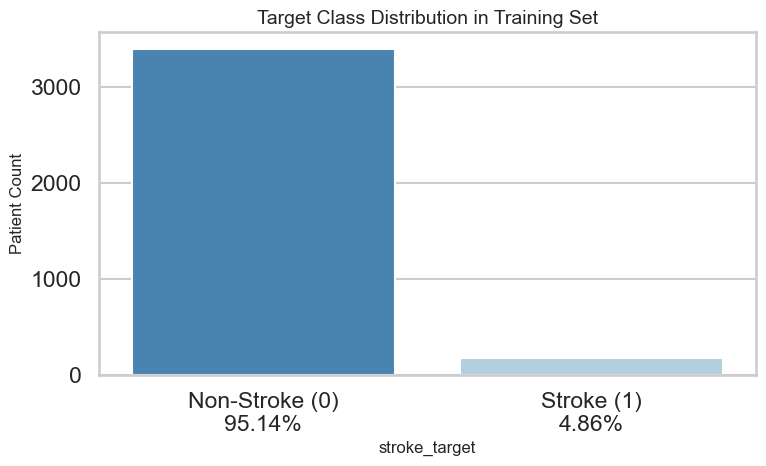

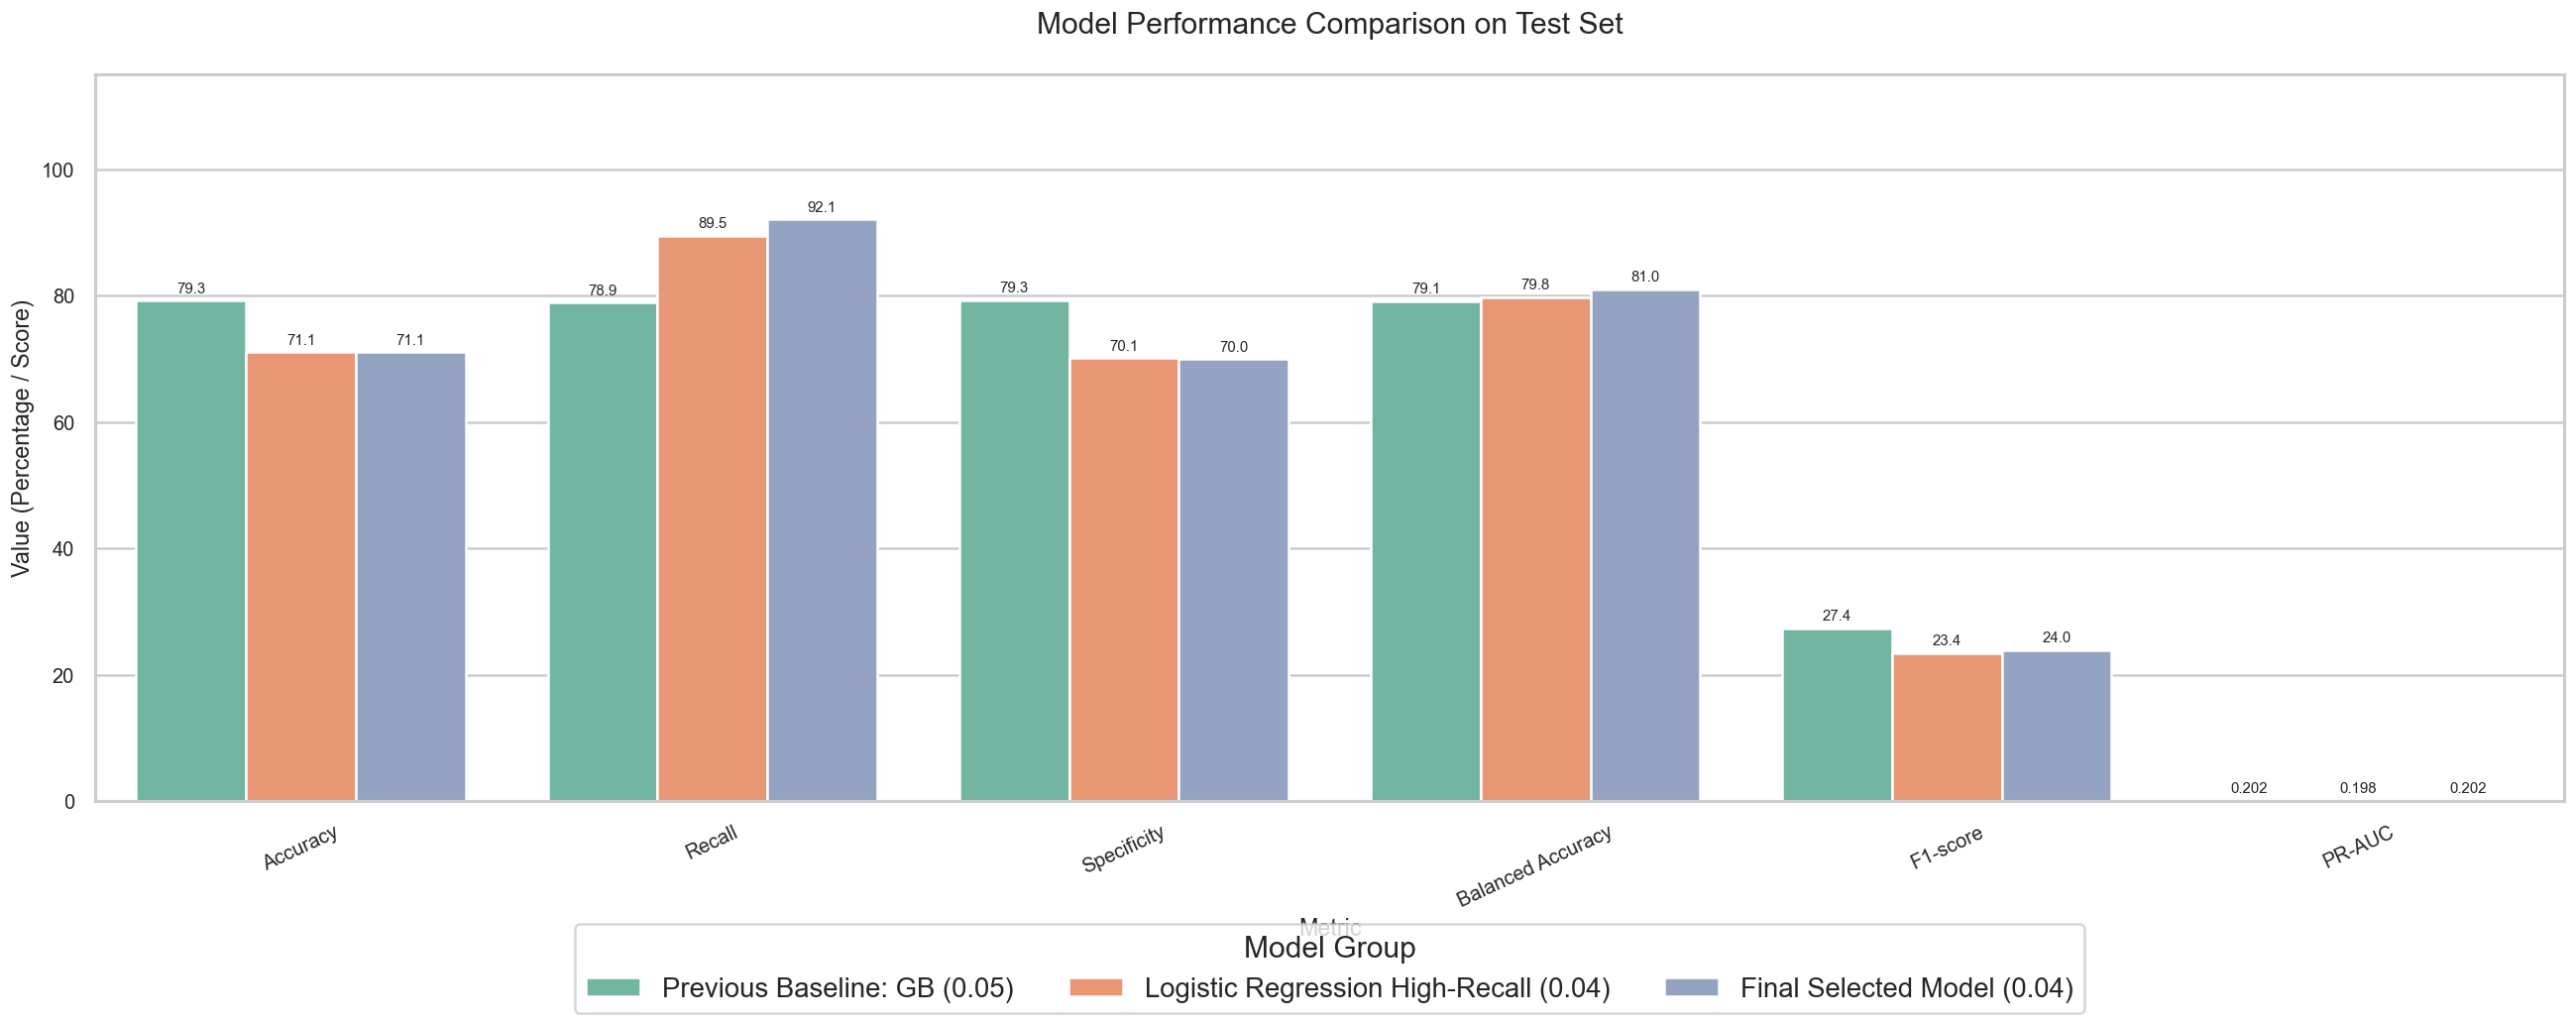

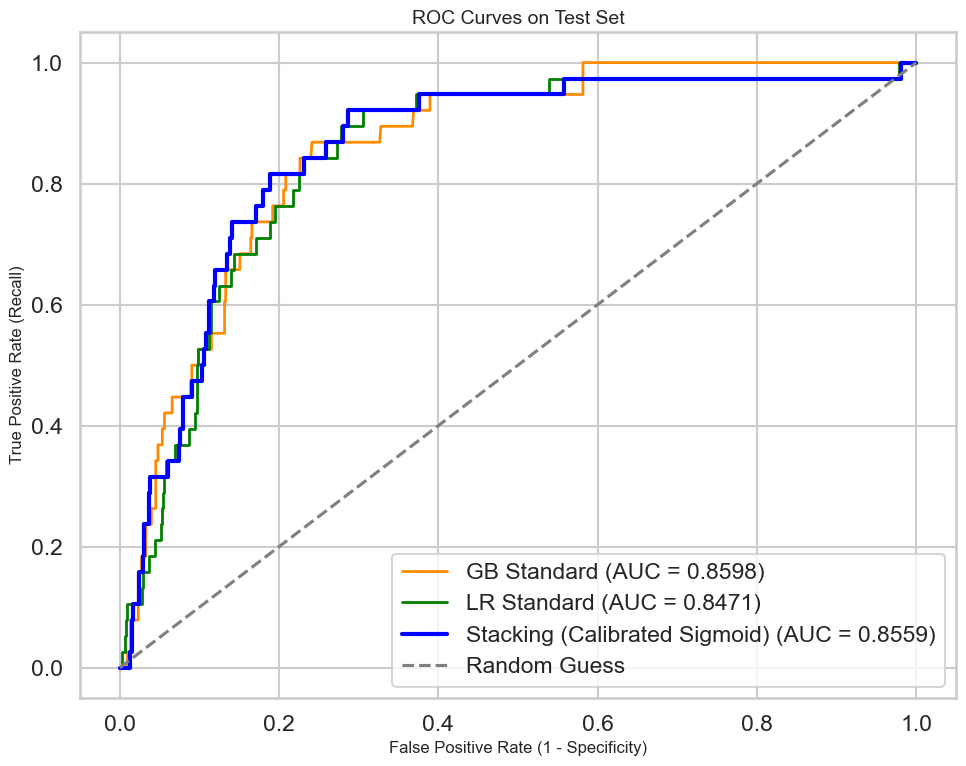

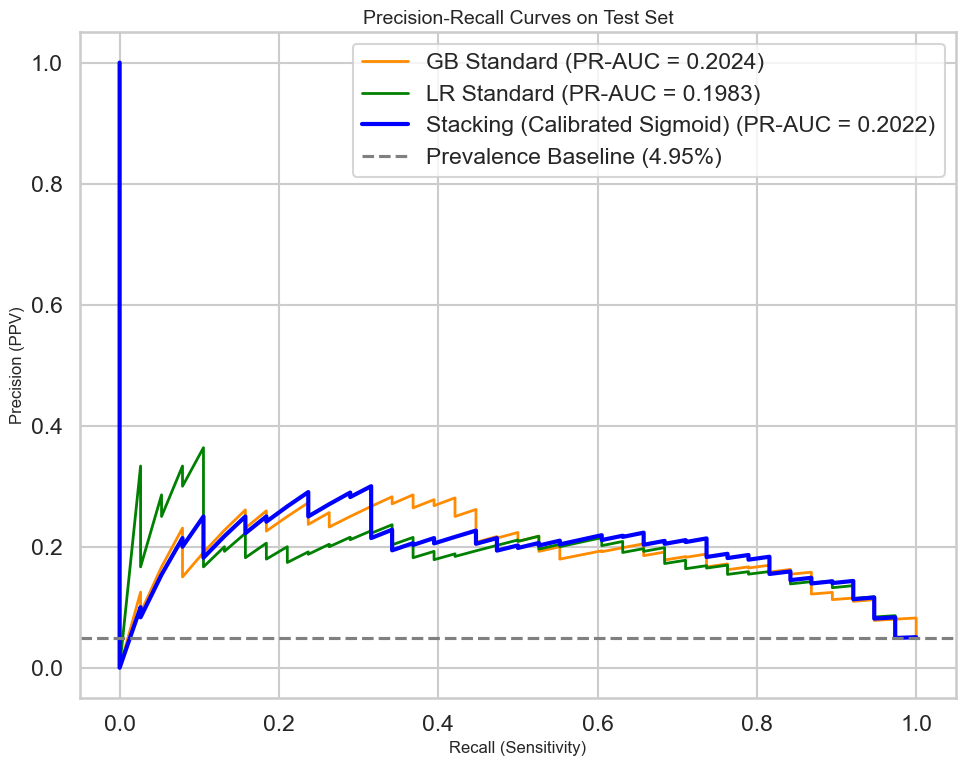

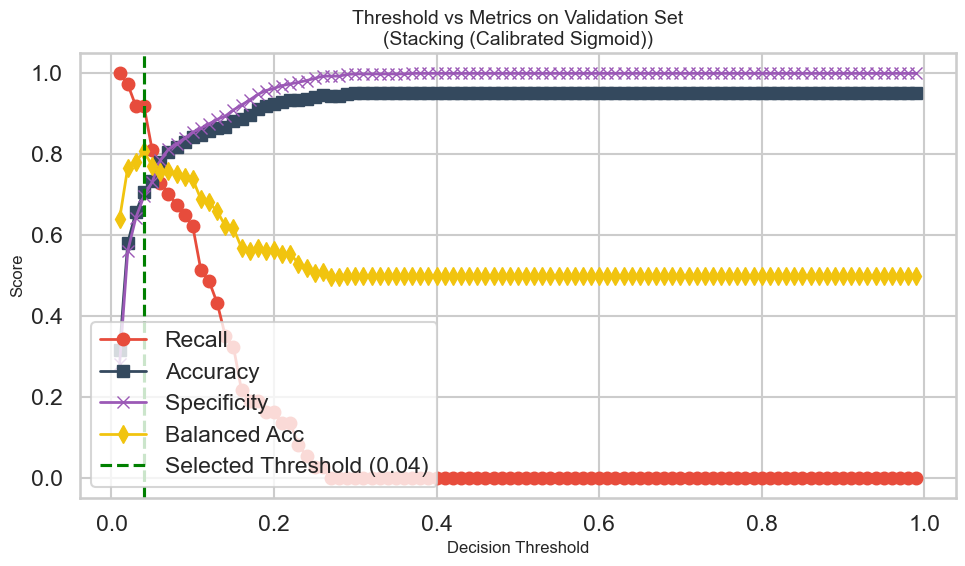

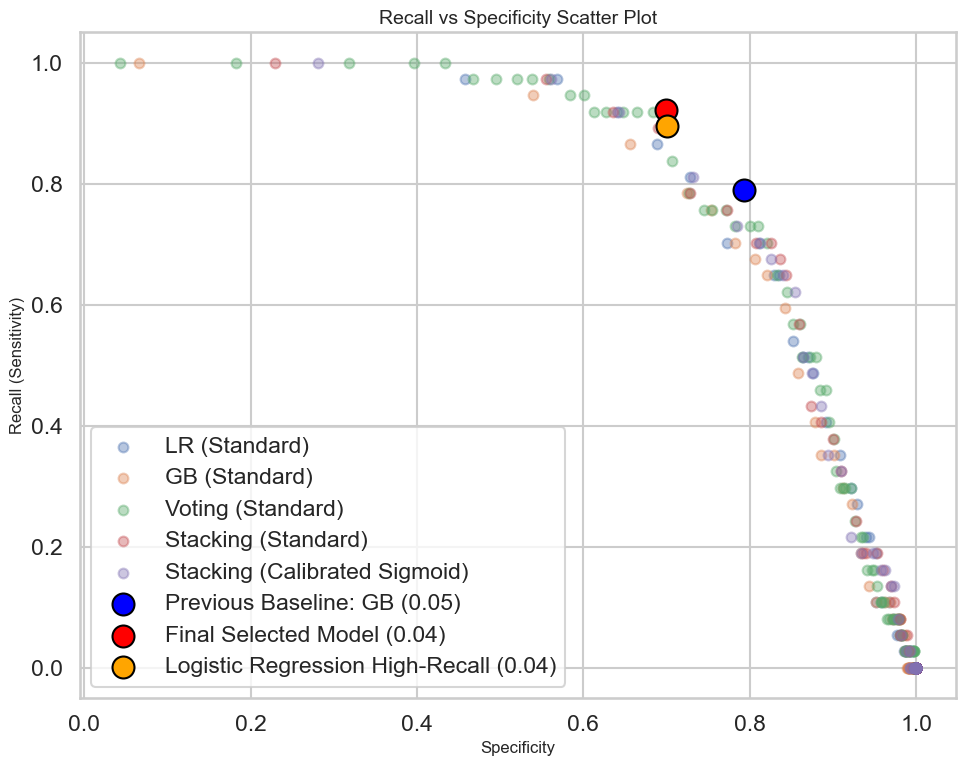

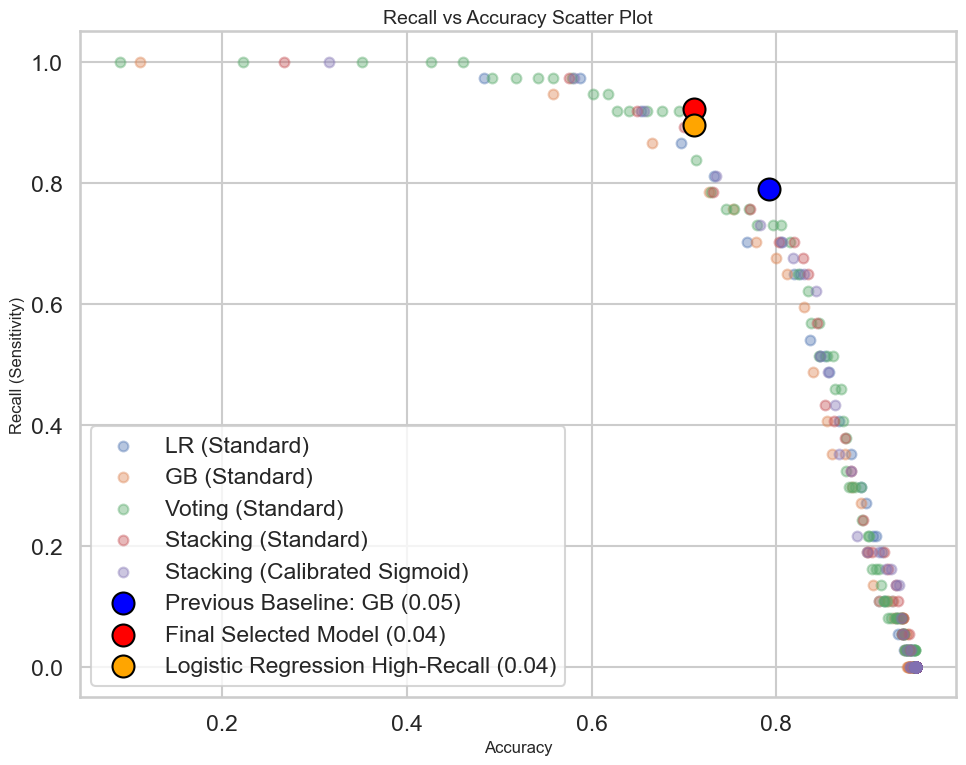

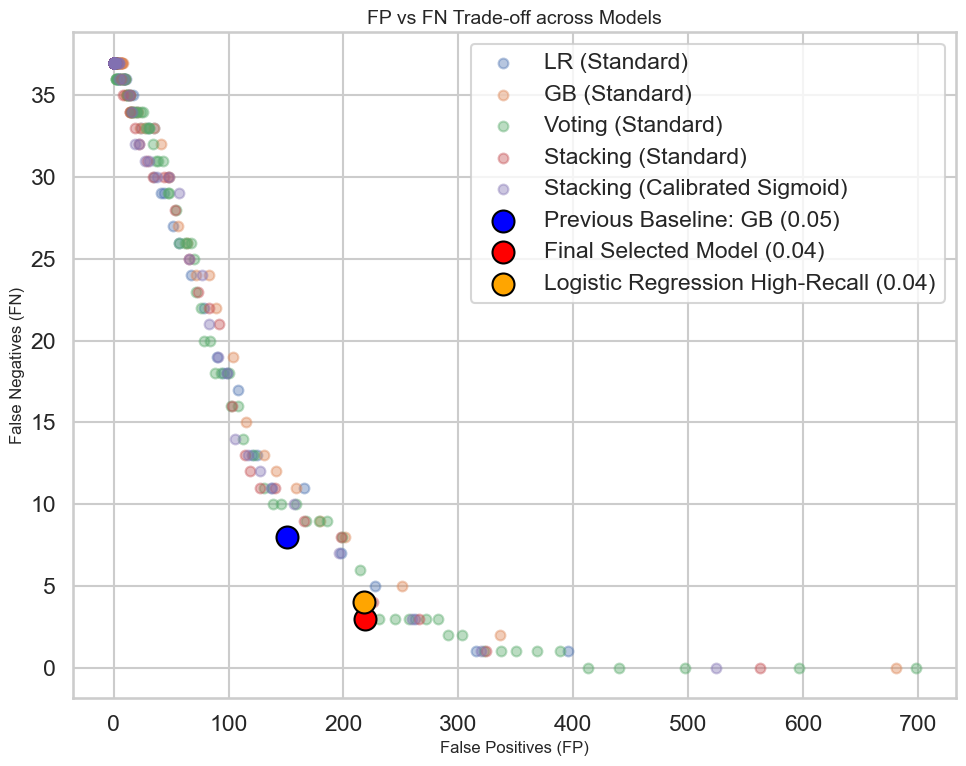

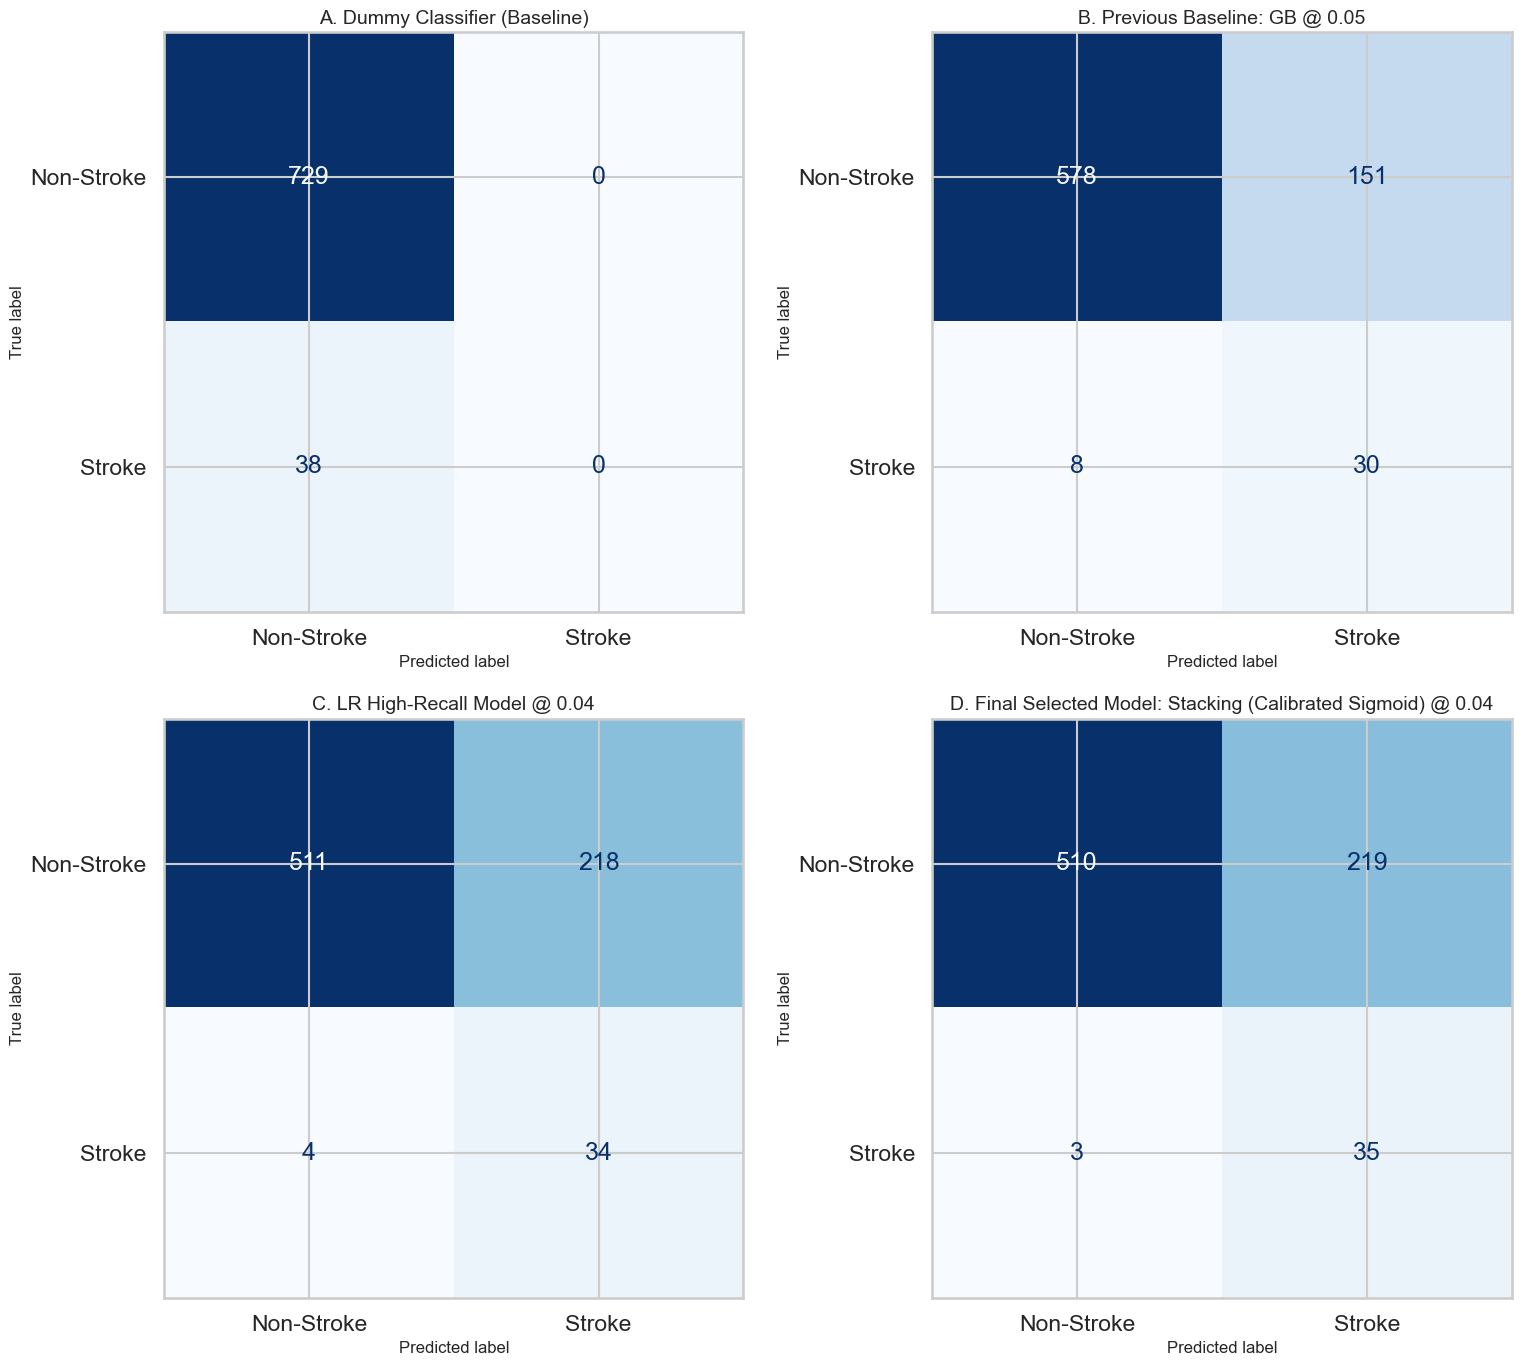

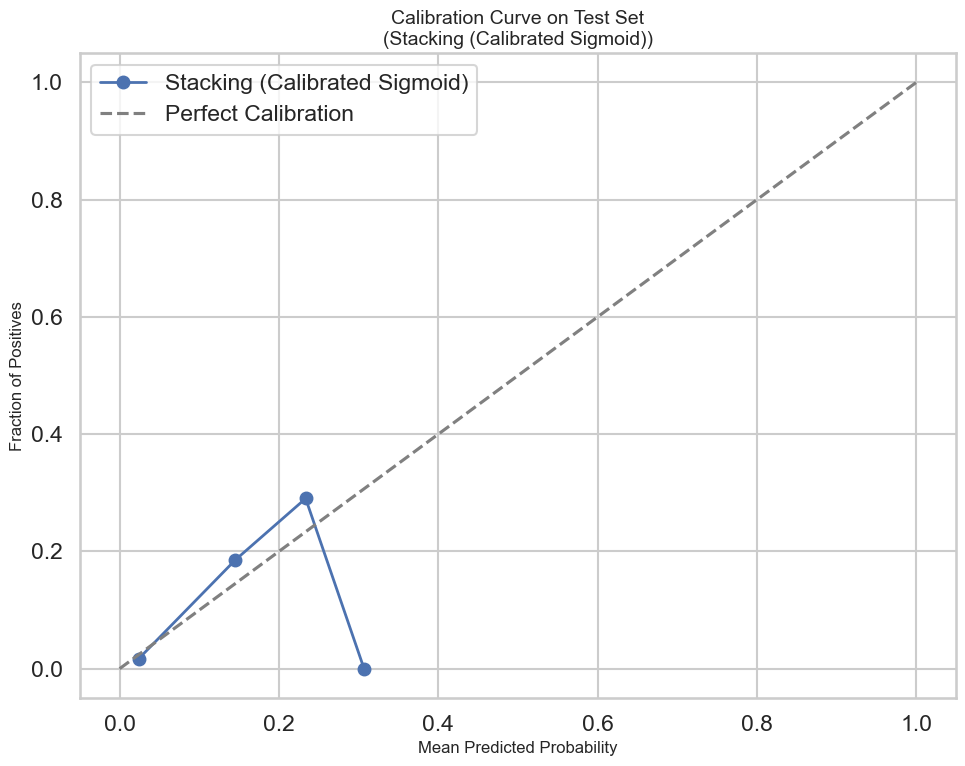

Calculating Permutation Importance...


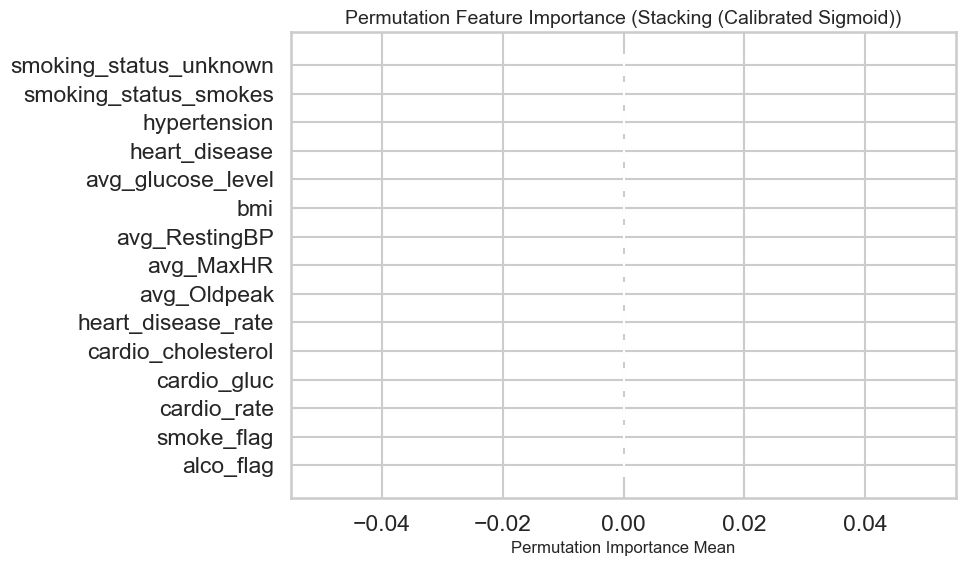

Calculating SHAP values...


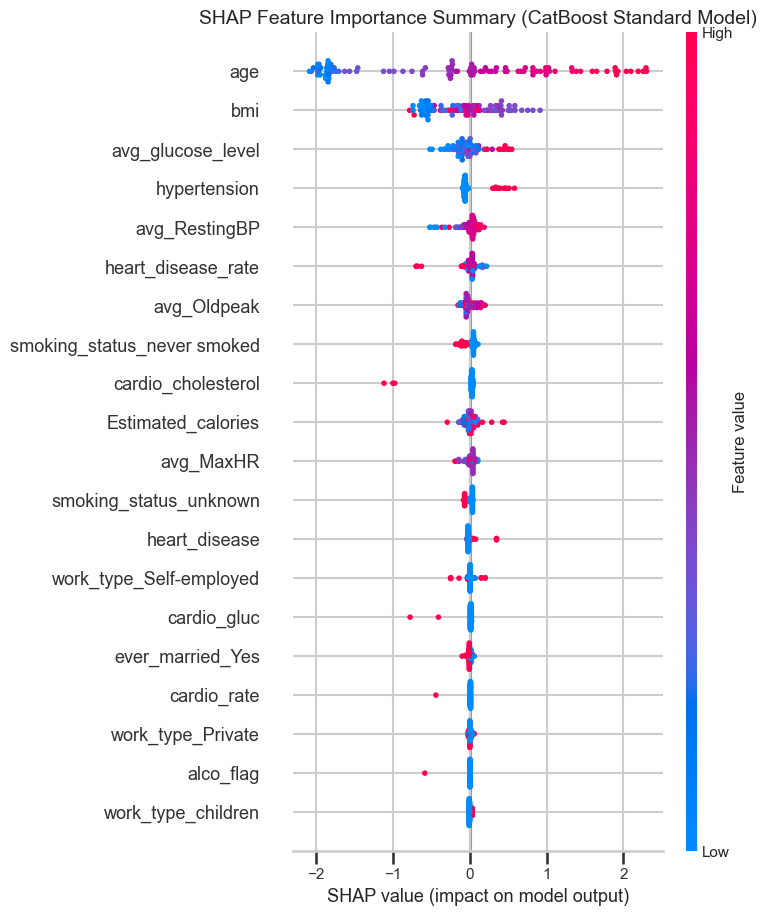

In [10]:
# Code cell: Clinical plots
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# 1. Target distribution chart
plt.figure(figsize=(8, 5))
counts = y_train.value_counts()
pcts = y_train.value_counts(normalize=True) * 100
sns.barplot(x=counts.index, y=counts.values, palette='Blues_r')
plt.xticks([0, 1], [f'Non-Stroke (0)\n{pcts[0]:.2f}%', f'Stroke (1)\n{pcts[1]:.2f}%'])
plt.ylabel('Patient Count')
plt.title('Target Class Distribution in Training Set')
plt.tight_layout()
plt.show()

# 2. Test model comparison bar chart
plt.figure(figsize=(22, 10), dpi=120)
metrics_to_plot = ['Accuracy', 'Recall', 'Specificity', 'Balanced Accuracy', 'F1-score', 'PR-AUC']
comparison_df = pd.DataFrame([
    {**baseline_row, 'Group': 'Previous Baseline: GB (0.05)'},
    {**prev_lr_row, 'Group': 'Logistic Regression High-Recall (0.04)'},
    {**final_row, 'Group': f'Final Selected Model ({final_thresh:.2f})'},
])

plot_data = []
for idx, r in comparison_df.iterrows():
    for m in metrics_to_plot:
        plot_data.append({
            'Model Group': r['Group'],
            'Metric': m,
            'Value (%)': r[m] * 100 if m not in ['ROC-AUC', 'PR-AUC'] else r[m]
        })
plot_df = pd.DataFrame(plot_data)

ax = sns.barplot(
    data=plot_df,
    x='Metric',
    y='Value (%)',
    hue='Model Group',
    palette='Set2'
)

ax.set_title(
    'Model Performance Comparison on Test Set',
    fontsize=18,
    pad=25
)

ax.set_xlabel('Metric', fontsize=14)
ax.set_ylabel('Value (Percentage / Score)', fontsize=14)

ax.set_ylim(0, 115)

ax.tick_params(axis='x', labelrotation=25, labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.legend(
    title='Model Group',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=True
)

for container in ax.containers:
    # Use 3 decimals for small values (like PR-AUC), 1 decimal for percentage values
    labels = [f'{v:.3f}' if v < 2.0 else f'{v:.1f}' for v in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

# 3. ROC curves for candidate models
plt.figure(figsize=(10, 8))
# GB Baseline
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_gb)
plt.plot(fpr_b, tpr_b, label=f'GB Standard (AUC = {roc_auc_b:.4f})', color='darkorange', linewidth=2)
# LR standard
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f'LR Standard (AUC = {roc_auc_lr:.4f})', color='green', linewidth=2)
# Selected model
fpr_sel, tpr_sel, _ = roc_curve(y_test, y_prob_sel)
plt.plot(fpr_sel, tpr_sel, label=f'{final_model_name} (AUC = {roc_auc_sel:.4f})', color='blue', linewidth=3)
# Random guess
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves on Test Set')
plt.legend()
plt.tight_layout()
plt.show()

# 4. PR curves for candidate models
plt.figure(figsize=(10, 8))
# GB Baseline
p_b, r_b, _ = precision_recall_curve(y_test, y_prob_gb)
plt.plot(r_b, p_b, label=f'GB Standard (PR-AUC = {pr_auc_b:.4f})', color='darkorange', linewidth=2)
# LR standard
p_lr, r_lr, _ = precision_recall_curve(y_test, y_prob_lr)
plt.plot(r_lr, p_lr, label=f'LR Standard (PR-AUC = {pr_auc_lr:.4f})', color='green', linewidth=2)
# Selected model
p_sel, r_sel, _ = precision_recall_curve(y_test, y_prob_sel)
plt.plot(r_sel, p_sel, label=f'{final_model_name} (PR-AUC = {pr_auc_sel:.4f})', color='blue', linewidth=3)
# Baseline prevalence
plt.axhline(y=y_test.mean(), linestyle='--', color='gray', label=f'Prevalence Baseline ({y_test.mean()*100:.2f}%)')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (PPV)')
plt.title('Precision-Recall Curves on Test Set')
plt.legend()
plt.tight_layout()
plt.show()

# 5. Threshold vs Metrics for Selected Model
df_curve = threshold_curves[final_model_name]
plt.figure(figsize=(10, 6))
plt.plot(df_curve['Threshold'], df_curve['Recall'], 'o-', label='Recall', color='#e74c3c', linewidth=2)
plt.plot(df_curve['Threshold'], df_curve['Accuracy'], 's-', label='Accuracy', color='#34495e', linewidth=2)
plt.plot(df_curve['Threshold'], df_curve['Specificity'], 'x-', label='Specificity', color='#9b59b6', linewidth=2)
plt.plot(df_curve['Threshold'], df_curve['Balanced Accuracy'], 'd-', label='Balanced Acc', color='#f1c40f', linewidth=2)
plt.axvline(x=final_thresh, color='green', linestyle='--', label=f'Selected Threshold ({final_thresh:.2f})')
plt.title(f'Threshold vs Metrics on Validation Set\n({final_model_name})')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

# 6. Recall vs Specificity scatter plot
plt.figure(figsize=(10, 8))
for name in ['LR (Standard)', 'GB (Standard)', 'Voting (Standard)', 'Stacking (Standard)', 'Stacking (Calibrated Sigmoid)']:
    if name in threshold_curves:
        df_c = threshold_curves[name]
        plt.scatter(df_c['Specificity'], df_c['Recall'], label=name, alpha=0.4, s=50)
plt.scatter(spec_b, rec_b, color='blue', edgecolor='black', s=250, zorder=5, label='Previous Baseline: GB (0.05)')
plt.scatter(spec_sel, rec_sel, color='red', edgecolor='black', s=250, zorder=5, label=f'Final Selected Model ({final_thresh:.2f})')
plt.scatter(spec_lr, rec_lr, color='orange', edgecolor='black', s=250, zorder=5, label='Logistic Regression High-Recall (0.04)')
plt.xlabel('Specificity')
plt.ylabel('Recall (Sensitivity)')
plt.title('Recall vs Specificity Scatter Plot')
plt.legend()
plt.tight_layout()
plt.show()

# 7. Recall vs Accuracy scatter plot
plt.figure(figsize=(10, 8))
for name in ['LR (Standard)', 'GB (Standard)', 'Voting (Standard)', 'Stacking (Standard)', 'Stacking (Calibrated Sigmoid)']:
    if name in threshold_curves:
        df_c = threshold_curves[name]
        plt.scatter(df_c['Accuracy'], df_c['Recall'], label=name, alpha=0.4, s=50)
plt.scatter(acc_b, rec_b, color='blue', edgecolor='black', s=250, zorder=5, label='Previous Baseline: GB (0.05)')
plt.scatter(acc_sel, rec_sel, color='red', edgecolor='black', s=250, zorder=5, label=f'Final Selected Model ({final_thresh:.2f})')
plt.scatter(acc_lr, rec_lr, color='orange', edgecolor='black', s=250, zorder=5, label='Logistic Regression High-Recall (0.04)')
plt.xlabel('Accuracy')
plt.ylabel('Recall (Sensitivity)')
plt.title('Recall vs Accuracy Scatter Plot')
plt.legend()
plt.tight_layout()
plt.show()

# 8. FP vs FN scatter plot
plt.figure(figsize=(10, 8))
for name in ['LR (Standard)', 'GB (Standard)', 'Voting (Standard)', 'Stacking (Standard)', 'Stacking (Calibrated Sigmoid)']:
    if name in threshold_curves:
        df_c = threshold_curves[name]
        plt.scatter(df_c['FP'], df_c['FN'], label=name, alpha=0.4, s=50)
plt.scatter(fp_b, fn_b, color='blue', edgecolor='black', s=250, zorder=5, label='Previous Baseline: GB (0.05)')
plt.scatter(fp_sel, fn_sel, color='red', edgecolor='black', s=250, zorder=5, label=f'Final Selected Model ({final_thresh:.2f})')
plt.scatter(fp_lr, fn_lr, color='orange', edgecolor='black', s=250, zorder=5, label='Logistic Regression High-Recall (0.04)')
plt.xlabel('False Positives (FP)')
plt.ylabel('False Negatives (FN)')
plt.title('FP vs FN Trade-off across Models')
plt.legend()
plt.tight_layout()
plt.show()

# 9. Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_dummy), display_labels=['Non-Stroke', 'Stroke']).plot(ax=axes[0, 0], cmap='Blues', colorbar=False)
axes[0, 0].set_title("A. Dummy Classifier (Baseline)")

ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_gb), display_labels=['Non-Stroke', 'Stroke']).plot(ax=axes[0, 1], cmap='Blues', colorbar=False)
axes[0, 1].set_title("B. Previous Baseline: GB @ 0.05")

ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_lr), display_labels=['Non-Stroke', 'Stroke']).plot(ax=axes[1, 0], cmap='Blues', colorbar=False)
axes[1, 0].set_title("C. LR High-Recall Model @ 0.04")

ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_sel), display_labels=['Non-Stroke', 'Stroke']).plot(ax=axes[1, 1], cmap='Blues', colorbar=False)
axes[1, 1].set_title(f"D. Final Selected Model: {final_model_name} @ {final_thresh:.2f}")
plt.tight_layout()
plt.show()

# 10. Calibration curve for final model
plt.figure(figsize=(10, 8))
prob_true, prob_pred = calibration_curve(y_test, y_prob_sel, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label=final_model_name)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title(f'Calibration Curve on Test Set\n({final_model_name})')
plt.legend()
plt.tight_layout()
plt.show()

# 11. Feature Importance: Permutation Importance
print("Calculating Permutation Importance...")
perm_importance = permutation_importance(sel_model, sel_xvl, y_val, n_repeats=5, random_state=42, n_jobs=-1)
sorted_idx = perm_importance.importances_mean.argsort()[-15:]
plt.figure(figsize=(10, 6))
plt.barh(sel_xvl.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance Mean")
plt.title(f"Permutation Feature Importance ({final_model_name})")
plt.tight_layout()
plt.show()

# 12. SHAP summary plot
print("Calculating SHAP values...")
cb_model_obj = test_cases['CatBoost (Standard)'][0]
explainer = shap.TreeExplainer(cb_model_obj)
X_val_sample = X_val.iloc[:100]  # Smaller sample for faster SHAP calculation
shap_values = explainer(X_val_sample)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val_sample, show=False)
plt.title("SHAP Feature Importance Summary (CatBoost Standard Model)")
plt.tight_layout()
plt.show()


### 4.4. Diễn giải kết quả mô hình được chọn
Mô hình **Stacking Classifier (Calibrated Sigmoid)** ở ngưỡng quyết định **0.04** được lựa chọn là mô hình tối ưu nhất cho bài toán sàng lọc đột quỵ. Các chỉ số hiệu năng cụ thể thu được trên tập kiểm thử (Test Set) độc lập bao gồm:
- **Accuracy (Độ chính xác):** 71.06%
- **Recall (Độ nhạy):** 92.11% (Phát hiện chính xác 35 trên tổng số 38 ca đột quỵ thực tế).
- **Specificity (Độ đặc hiệu):** 69.96% (Dự đoán đúng 510 trên 726 ca khỏe mạnh).
- **Balanced Accuracy (Độ chính xác cân bằng):** 81.03%
- **Precision (Độ chuẩn xác):** 13.78% (Tỷ lệ người đột quỵ thực tế trong số các ca được cảnh báo).
- **F1-score:** 23.97%
- **ROC-AUC:** 0.8559
- **PR-AUC:** 0.2022

#### Phân tích Ma trận Nhầm lẫn (Confusion Matrix):
- **True Positives (TP - Dương tính thật):** **35 ca** (mẫu đột quỵ được cảnh báo đúng).
- **False Negatives (FN - Âm tính giả):** **3 ca** (bệnh nhân đột quỵ thực tế bị mô hình bỏ sót).
- **False Positives (FP - Dương tính giả):** **219 ca** (mẫu khỏe mạnh bị gắn cờ cảnh báo đột quỵ).
- **True Negatives (TN - Âm tính thật):** **510 ca** (mẫu khỏe mạnh được dự đoán đúng).

#### Đánh giá sự đánh đổi lâm sàng (Clinical Trade-off):
Mô hình đáp ứng xuất sắc yêu cầu y tế là tối thiểu hóa tỷ lệ âm tính giả (chỉ bỏ sót 3 ca đột quỵ trên tập Test). Tuy nhiên, để đạt được độ nhạy 92.11% này, mô hình phải đánh đổi bằng Specificity (69.96%) và Precision (13.78%), tạo ra **219 ca cảnh báo giả**. Điều này có nghĩa là trong thực tế, cứ 7 bệnh nhân được mô hình gắn cờ cảnh báo thì sẽ có 1 bệnh nhân thực sự bị đột quỵ. Đây là mức đánh đổi hoàn toàn chấp nhận được đối với công cụ sàng lọc sơ bộ không xâm lấn, nhưng cần lưu ý để tránh hiện tượng mệt mỏi cảnh báo (alert fatigue) trong thực tế lâm sàng.

#### So sánh với các baseline:
- **So với Dummy Classifier (Accuracy 95.05%, Recall 0%):** Mô hình Dummy có độ chính xác cao nhưng hoàn toàn vô dụng vì bỏ sót 100% ca đột quỵ thực tế, cho thấy Accuracy đơn độc là chỉ số đánh giá sai lệch trong dữ liệu lệch lớp.
- **So với Gradient Boosting Baseline @ 0.05 (Recall 78.95%, FN 8, FP 151):** Mô hình Stacking Calibrated Sigmoid cải thiện vượt bậc độ nhạy (+13.16%), phát hiện thêm 5 ca đột quỵ thực tế nguy hiểm (giảm FN từ 8 xuống còn 3 ca), tăng Balanced Accuracy từ 79.12% lên 81.03%.
- **So với Logistic Regression High-Recall Model @ 0.04 (Recall 89.47%, FN 4, FP 218):** Mô hình Stacking Calibrated Sigmoid phát hiện thêm 1 ca đột quỵ thực tế (Recall 92.11% vs. 89.47%) và cải thiện F1-score cũng như PR-AUC, trong khi giữ mức cảnh báo giả tương đương (219 vs. 218 FP).

### 4.5. Kết luận và Khuyến nghị (Conclusion & Recommendations)

#### Tóm tắt kết quả chính
- Nghiên cứu đã xây dựng và tinh chỉnh thành công mô hình dự báo đột quỵ trên tập dữ liệu mất cân bằng.
- Việc đánh giá mô hình dựa trên độ chính xác đơn độc (Accuracy) là hoàn toàn sai lệch. Cần kết hợp đa chỉ số (Recall, Specificity, Balanced Accuracy và PR-AUC) để đưa ra quyết định lâm sàng tối ưu.
- Mô hình đề xuất cuối cùng là **Stacking Classifier (Calibrated Sigmoid)** ở ngưỡng quyết định **0.04**.

#### Tuyên bố về khả năng ứng dụng lâm sàng
> **[IMPORTANT]**  
> Mô hình cuối cùng phù hợp nhất để sử dụng như một công cụ hỗ trợ sàng lọc nguy cơ đột quỵ ban đầu hoặc hệ thống hỗ trợ ra quyết định lâm sàng sơ bộ. Tuy nhiên, mô hình **chưa đủ điều kiện và không được phép sử dụng như một hệ thống chẩn đoán độc lập trong thực tế lâm sàng**. Mọi quyết định chẩn đoán và điều trị cuối cùng phải được đưa ra bởi bác sĩ chuyên khoa dựa trên các xét nghiệm cận lâm sàng chuyên sâu.

#### Hạn chế của mô hình
1. **Tỷ lệ cảnh báo giả còn cao (FP = 219, Precision = 13.78%):** Có thể dẫn đến căng thẳng tâm lý không cần thiết cho người khỏe mạnh và gây mệt mỏi cảnh báo cho nhân viên y tế.
2. **Cỡ mẫu nhỏ và số ca dương tính rất ít:** Tập huấn luyện chỉ có 87 ca đột quỵ và tập kiểm thử chỉ có 38 ca dương tính, dẫn đến độ nhạy của các độ đo rất cao và tăng nguy cơ overfitting cục bộ.
3. **Thiếu đánh giá độc lập bên ngoài (External Validation):** Mô hình mới chỉ được huấn luyện và đánh giá trên các tập cắt chia từ cùng một tập dữ liệu gốc, chưa được kiểm định trên các quần thể bệnh nhân hoặc bệnh viện khác biệt.

#### Đề xuất cải thiện và hướng phát triển tương lai
- **Thu thập thêm dữ liệu:** Đặc biệt là dữ liệu của bệnh nhân đột quỵ thực tế để cải thiện khả năng học của mô hình trên lớp thiểu số.
- **Thử nghiệm kiểm định bên ngoài (External Validation):** Thử nghiệm chạy mô hình trên dữ liệu y tế từ các bệnh viện hoặc nguồn dữ liệu độc lập khác để đánh giá độ bền (robustness) và tính tổng quát hóa.
- **Tối ưu hóa ngưỡng theo chi phí lâm sàng:** Phối hợp với các nhà quản lý y tế và bác sĩ để xây dựng hàm chi phí kinh tế - sức khỏe cụ thể cho các ca bỏ sót (FN) và báo động sai (FP) để tìm ra ngưỡng quyết định tối ưu về chi phí xã hội.
- **Giải thích mô hình (SHAP/LIME):** Tích hợp các công cụ giải thích đóng góp của từng đặc trưng (SHAP value) giúp bác sĩ hiểu rõ lý do vì sao mô hình đưa ra cảnh báo nguy cơ cao cho từng bệnh nhân cụ thể.
- **Kiểm tra tính công bằng (Fairness & Bias Audit):** Đánh giá xem mô hình có đưa ra các dự đoán thiên vị hoặc kém chính xác hơn trên các nhóm nhân khẩu học cụ thể (như giới tính, độ tuổi, hoặc tình trạng hút thuốc) hay không.